Created 3/14/2022 

Differentiating between good and bad models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [ ]:
#lets start with unitdifference reward function because we have already figured out the best rew_threshold for that.And also start with 
#sir3 vs. sir3_chunk models.  (as opposed to sir2)
#Let us start by visualizing sir3 and sir3_chunk, 
#        1) histograms for all models
#       2)learning curves for individual models. 
#       3) write function to take cut off for last value in learing curve and separate between good and bad models. 
#       4) separate histograms for bad and good models 
#lets use rew_threshold 5, Remember everything should be for FULL RANGE (not the narrow stim)

Text(0, 0.5, 'Frequency')

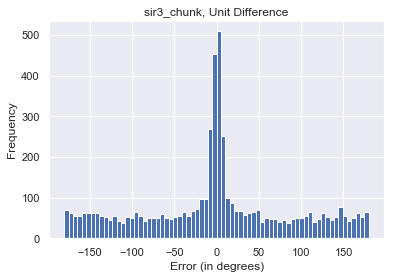

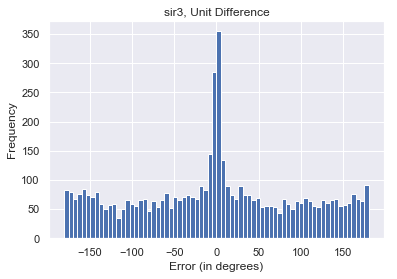

In [2]:
#This is step 1: visualize histograms for all models for sir3 and sir3 chunk (remember this is for rewthresh5) and for full range 
base_file = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/RewThresh5/"
if "StimRange0to45" in base_file:
    model_name = base_file.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base_file.split('workingmemory')[1].split('/')[1] 
if base_file.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", "+rewardfun)
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

base_file = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/RewThresh5/"
if "StimRange0to45" in base_file:
    model_name = base_file.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base_file.split('workingmemory')[1].split('/')[1] 
if base_file.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", "+rewardfun)
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

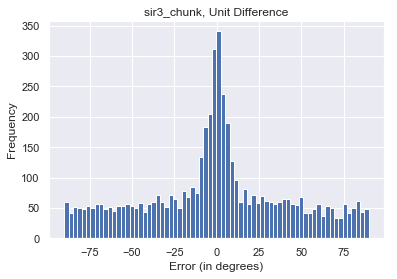

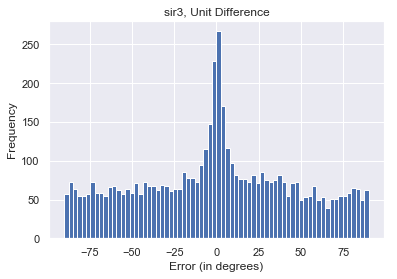

In [12]:
#This is step 1: visualize histograms for all models for sir3 and sir3 chunk (remember this is for rewthresh5) and for full range 
base_file = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/RewThresh5/"
if "StimRange0to45" in base_file:
    model_name = base_file.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base_file.split('workingmemory')[1].split('/')[1] 
if base_file.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", "+rewardfun)
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

base_file = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/RewThresh5/"
if "StimRange0to45" in base_file:
    model_name = base_file.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base_file.split('workingmemory')[1].split('/')[1] 
if base_file.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", "+rewardfun)
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

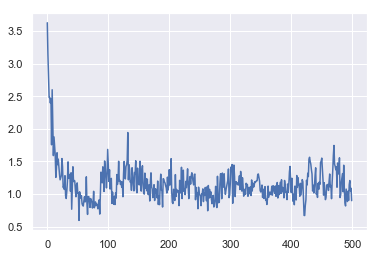

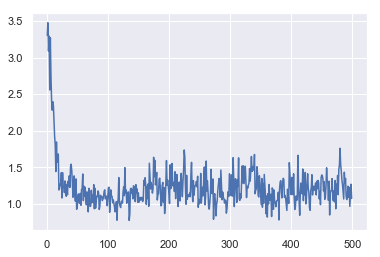

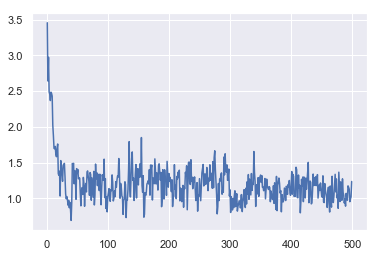

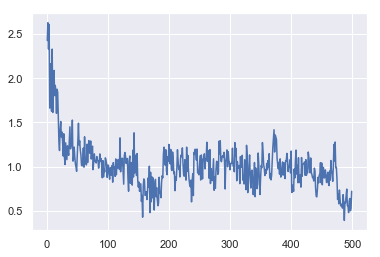

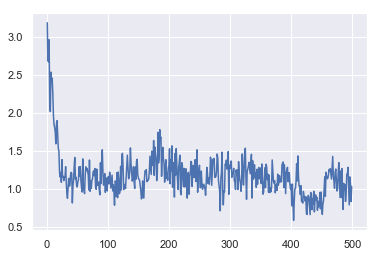

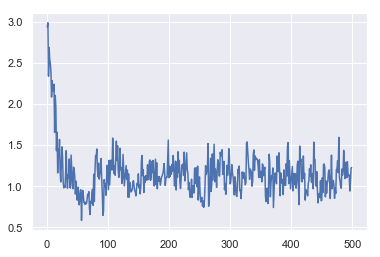

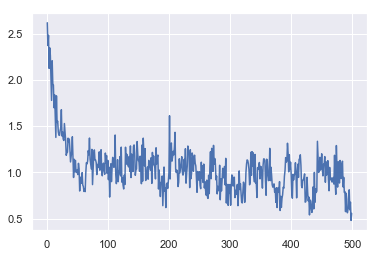

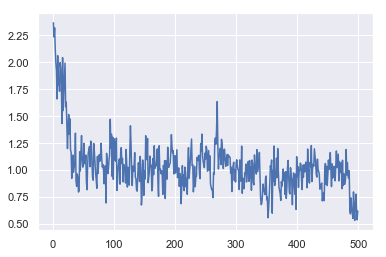

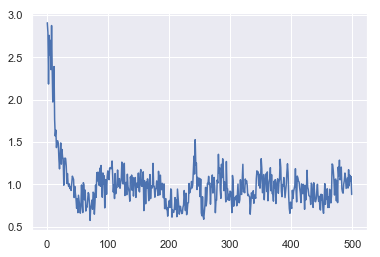

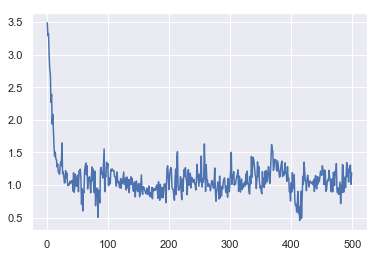

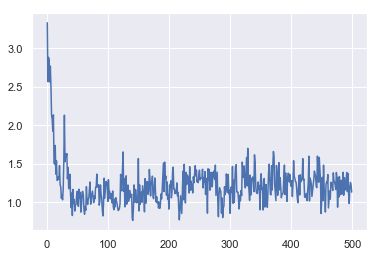

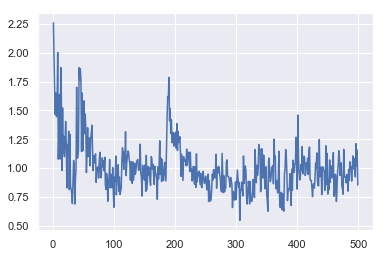

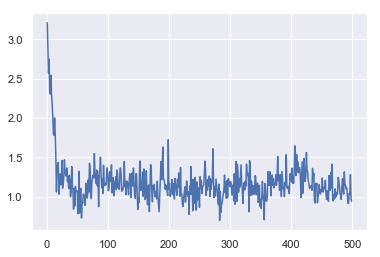

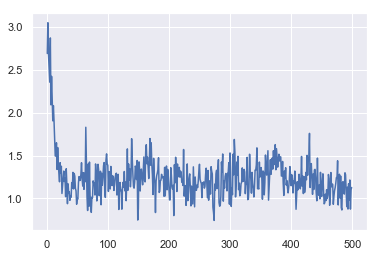

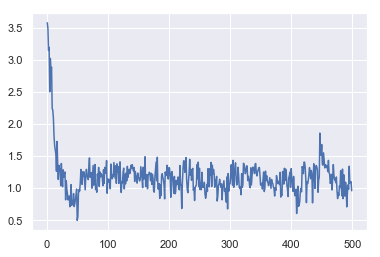

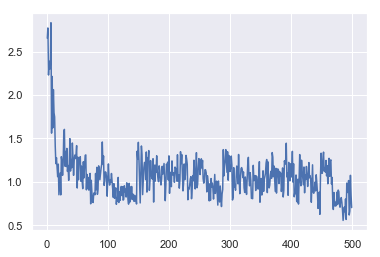

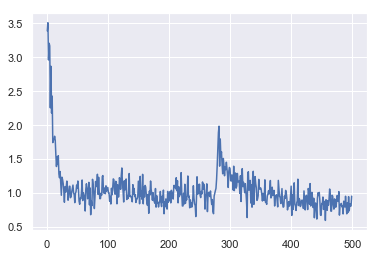

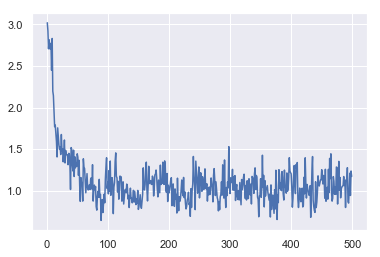

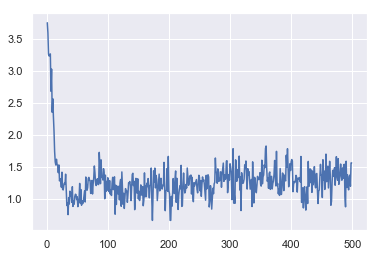

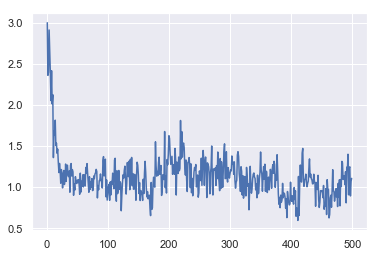

In [2]:
#This is step 2 - lets plot the inidivual curves for sir3_chunk
training_curve_indv("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/RewThresh5/")

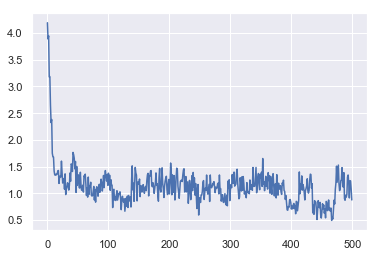

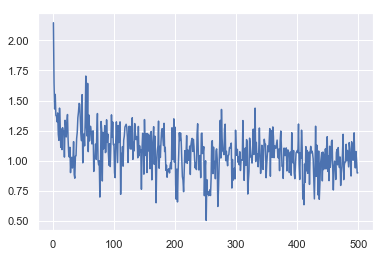

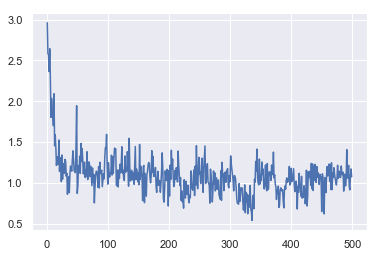

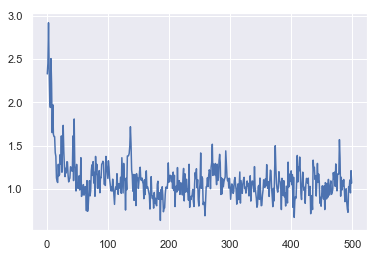

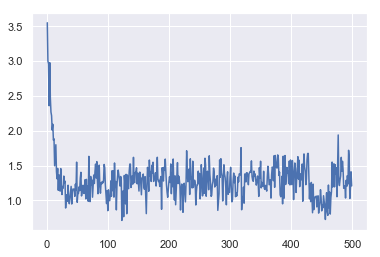

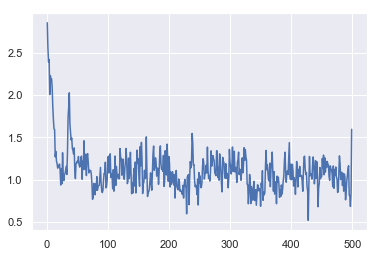

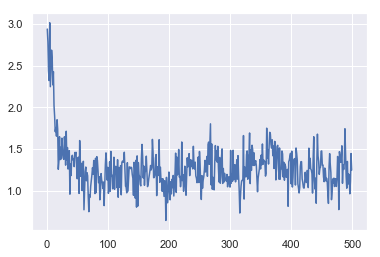

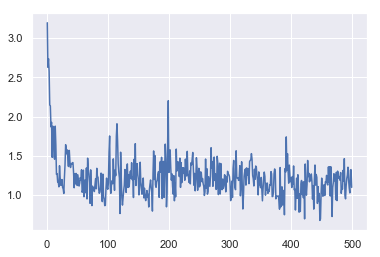

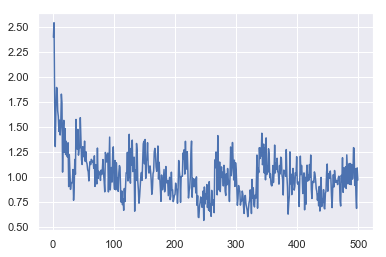

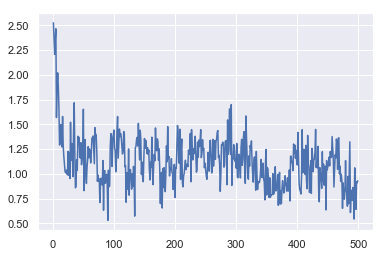

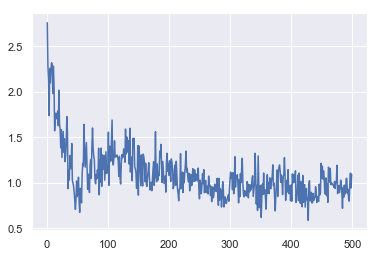

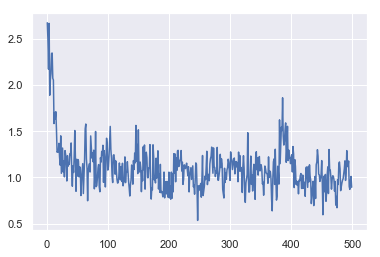

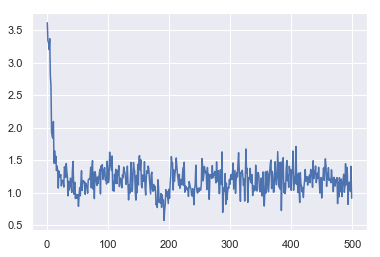

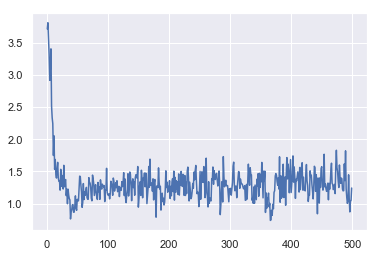

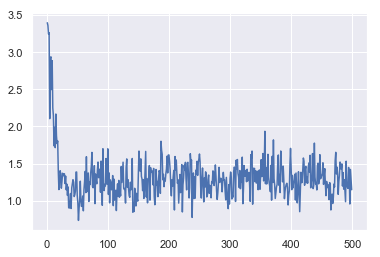

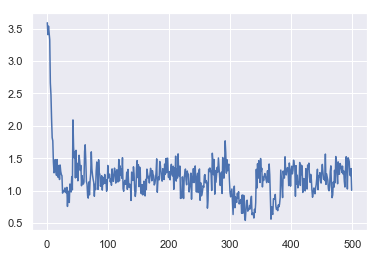

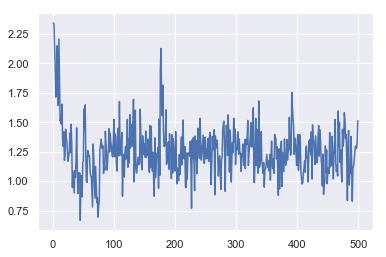

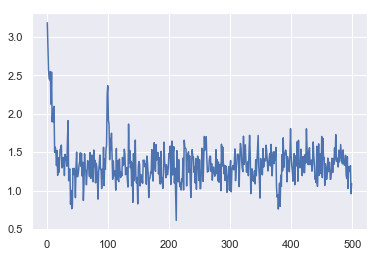

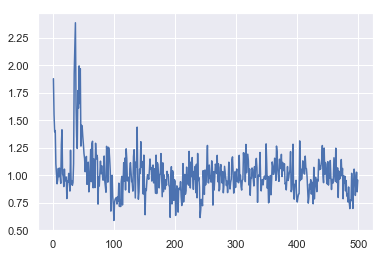

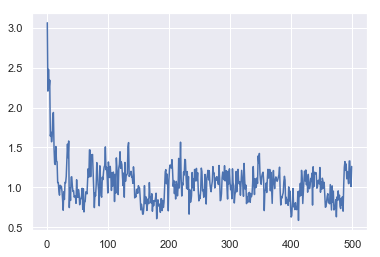

In [7]:
#This is step 2b - lets plot the individual curve for sir3
training_curve_indv("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/RewThresh5/")

In [ ]:
#based on looking at the above plots, Lets make the cut off 1; 

In [7]:
#This is step 3

def badmodels(base,cutoff = 1.0): #this should return a list where first part is fullfilename of all the bad models, then all good models. 
    files = os.listdir(base)
    full_files = [base+f for f in files if 'EpcLog' in f]
    
    good = []
    bad =[]
    
    for f in full_files:
        if 'model0_' in f:
            df = pd.read_csv(f, sep = '\t')
            SSE = df['#SSE']
            Epoch = df['|Epoch']
        else:
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE  = df[2]
            Epoch = df[1]
        #import pdb; pdb.set_trace()
        f_hist = f.replace('EpcLog', '')
        if SSE.iloc[-1] <=cutoff:
            good.append(f_hist)
        else:
            bad.append(f_hist)
    
    return bad, good

def plotbadmodels(bad,good,cutof = 1.0):#this should take the fullfilenames of all good,bad models and plot 3 plots - 1 good,1bad, 1 all. 
    allmod = bad+good
    model_name = allmod[0].split('workingmemory')[1].split('/')[1]
    if 'decodedrew' in allmod[0]:
        rewardfun = 'Decoded'
    else:
        rewardfun = 'Unit Difference'
        
    plt.figure()
    p = Precision()
    err = p.mult_models(allmod)
    nummodels = len(allmod)
    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+" ,"+str(nummodels)+"All Models")
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')
        
    plt.figure()
    p = Precision()
    nummodels = len(bad)
    if nummodels == 0:
        print('0 Bad Models')
        return
    err = p.mult_models(bad)
    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+" ,"+str(nummodels)+"Bad Models")
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')

    plt.figure()
    p = Precision()
    nummodels = len(good)
    if nummodels == 0:
        print('0 Good Models')
        return
    err = p.mult_models(good)

    plt.hist(err, bins = 70)
    plt.title(model_name+", "+rewardfun+" ,"+str(nummodels)+"Good Models")
    plt.xlabel('Error (in degrees)')
    plt.ylabel('Frequency')



    

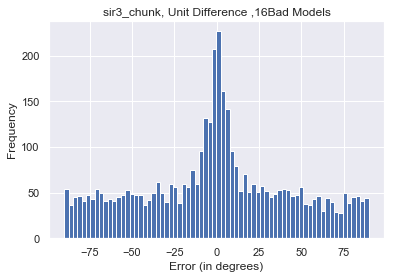

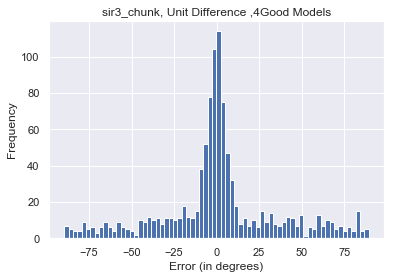

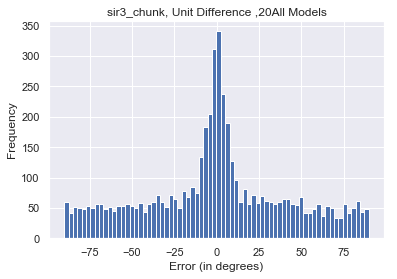

In [43]:
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/RewThresh5/", cutoff = 0.75 )
plotbadmodels(bad,good)

0 Good Models


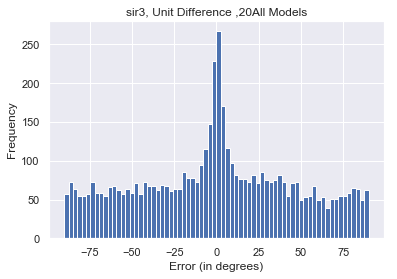

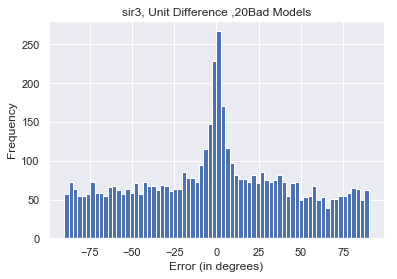

<Figure size 432x288 with 0 Axes>

In [52]:
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/RewThresh5/", cutoff = 0.75 )
plotbadmodels(bad,good)

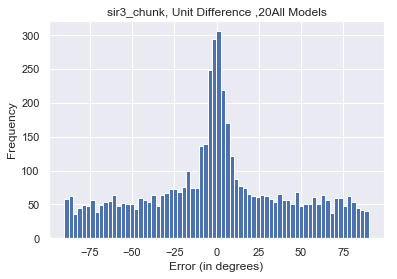

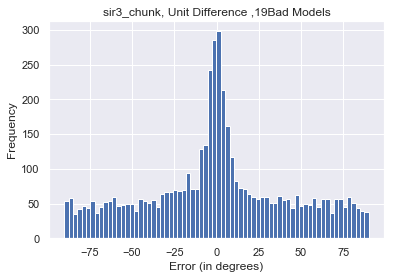

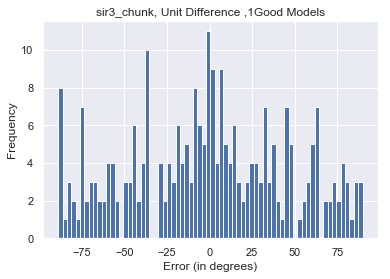

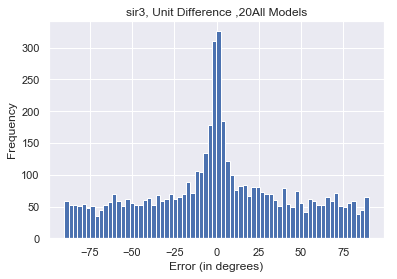

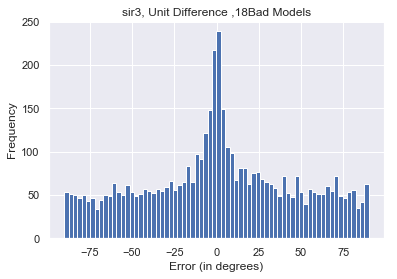

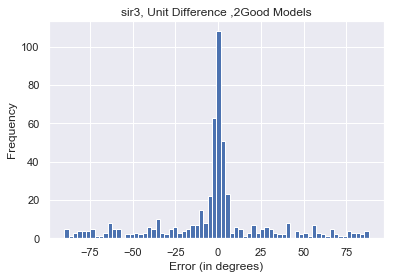

In [59]:
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/RewThresh7/", cutoff = 0.75 )
plotbadmodels(bad,good)
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/RewThresh7/", cutoff = 0.75 )
plotbadmodels(bad,good)

In [6]:
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/", cutoff = 80 )
plotbadmodels(bad,good)
bad,good = badmodels("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/", cutoff= 80)
plotbadmodels(bad,good)

NameError: name 'badmodels' is not defined

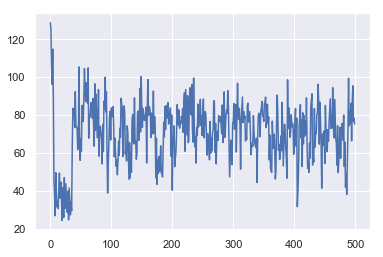

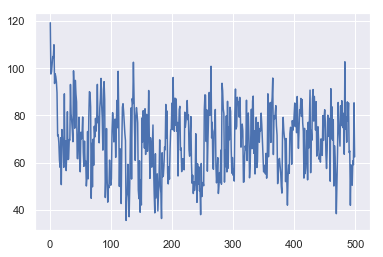

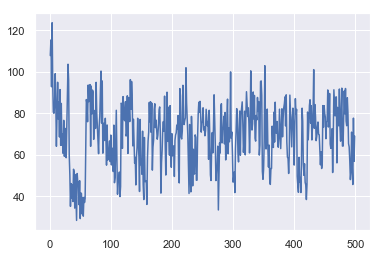

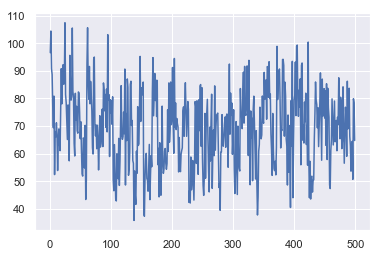

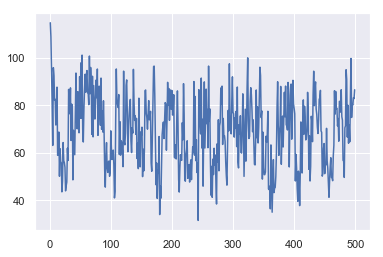

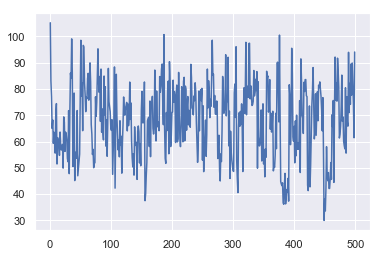

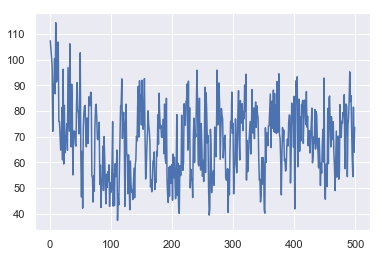

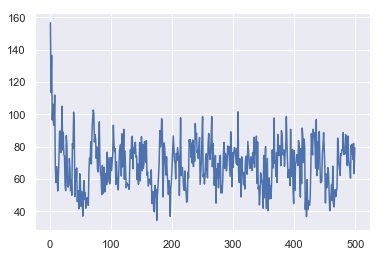

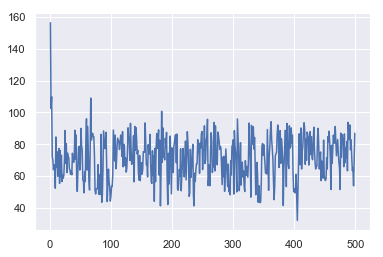

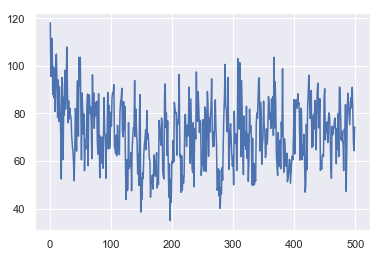

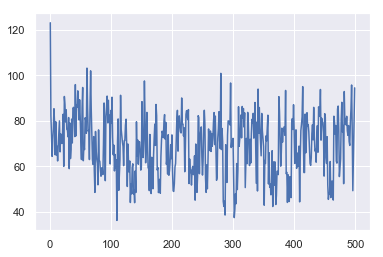

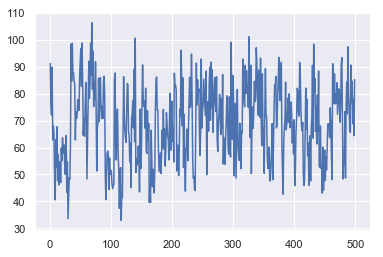

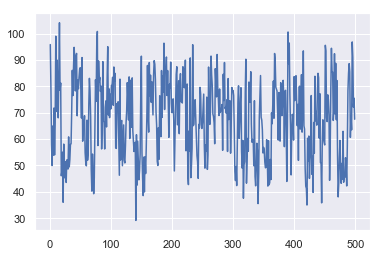

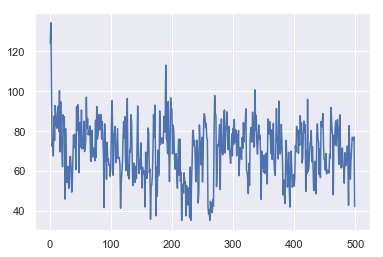

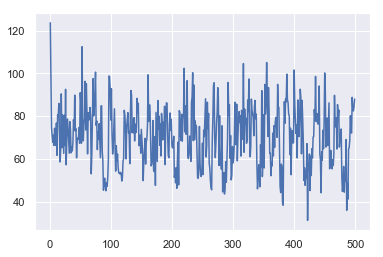

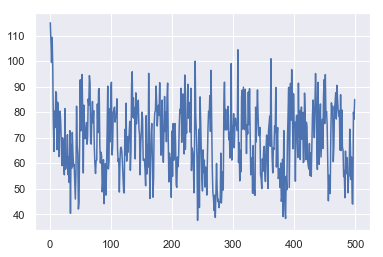

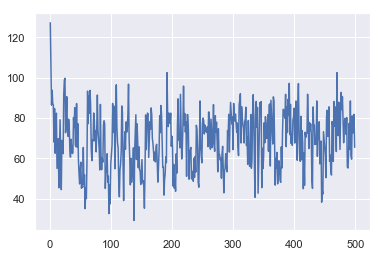

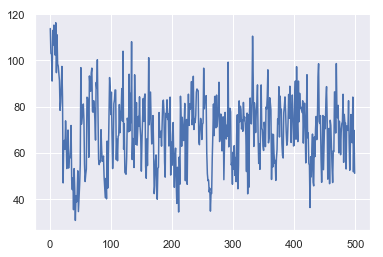

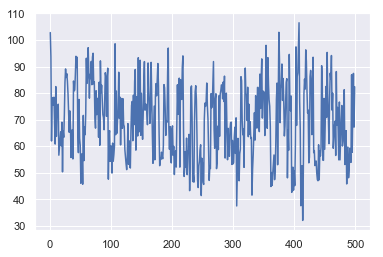

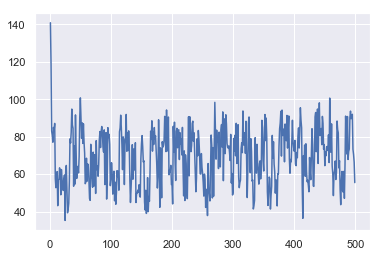

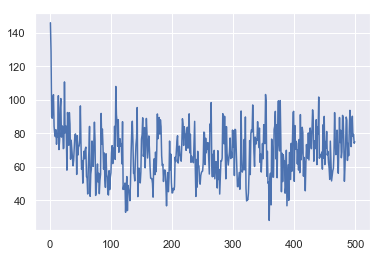

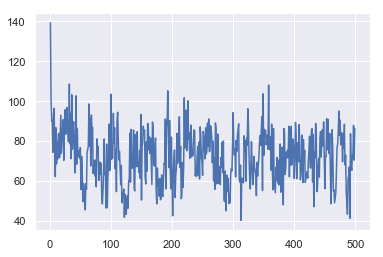

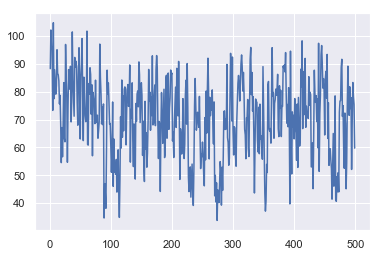

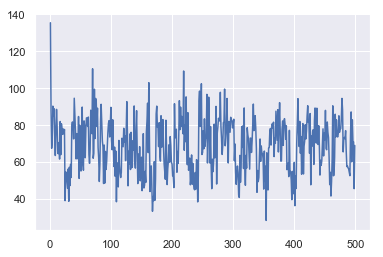

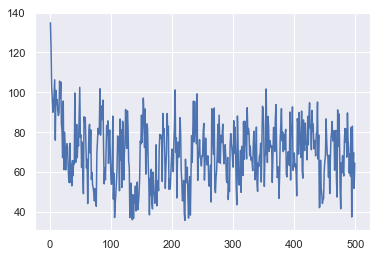

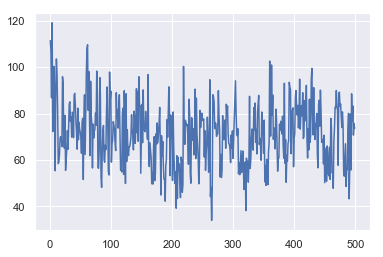

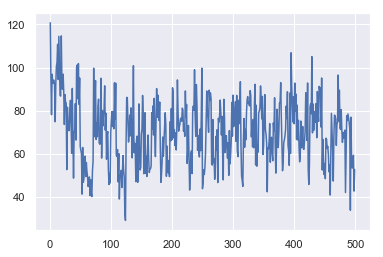

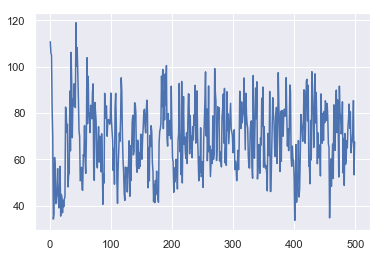

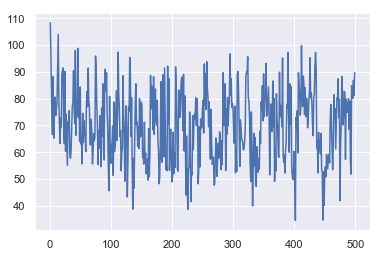

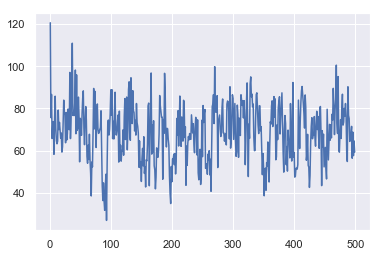

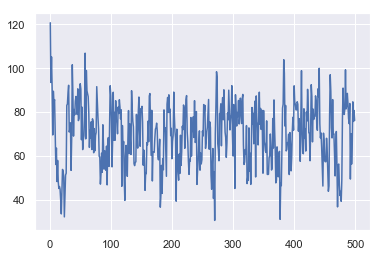

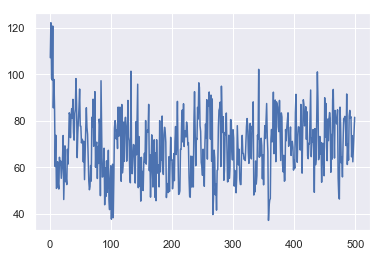

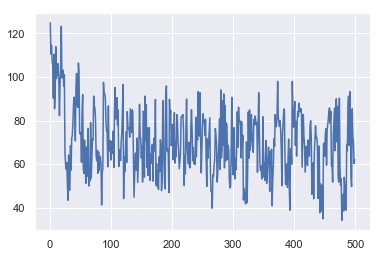

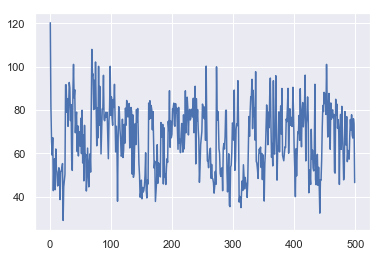

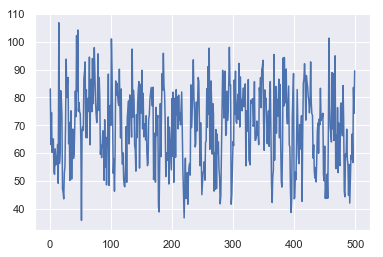

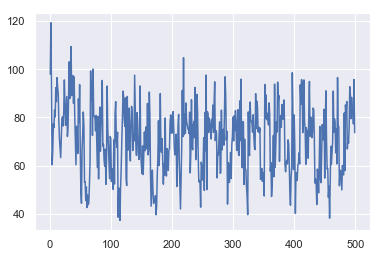

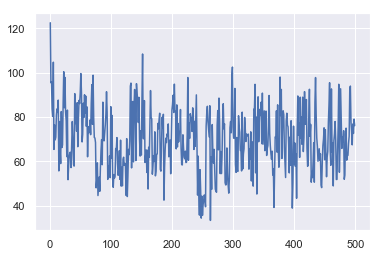

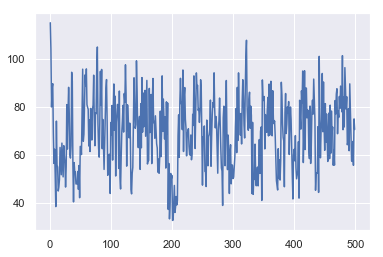

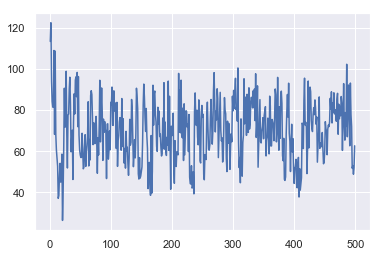

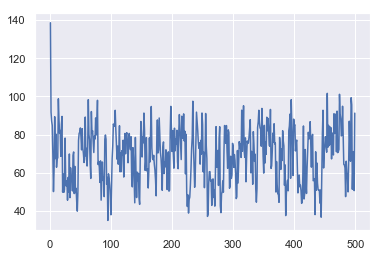

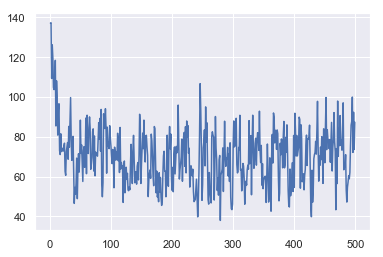

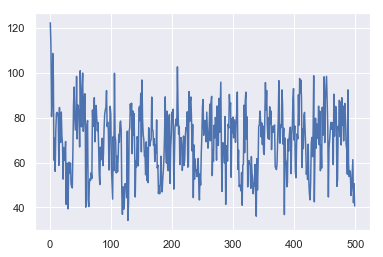

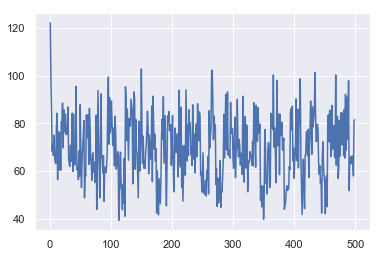

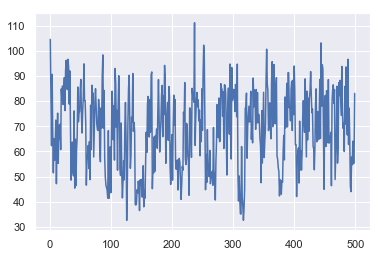

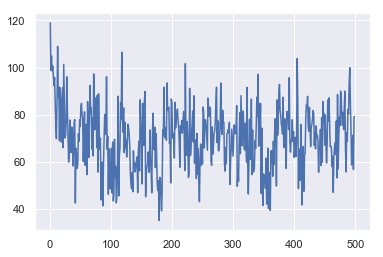

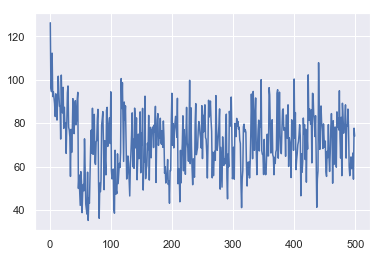

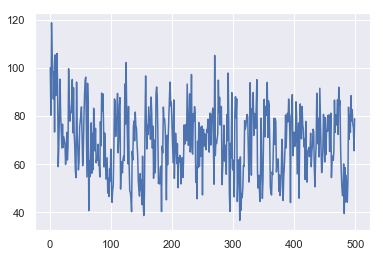

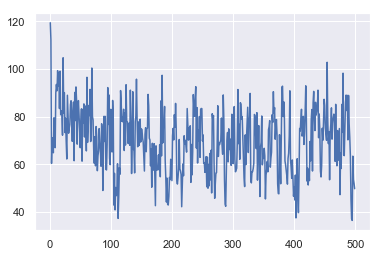

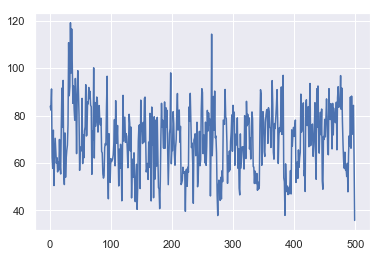

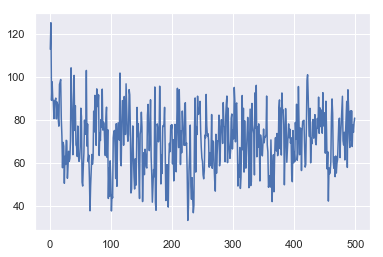

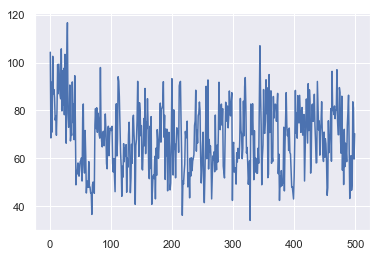

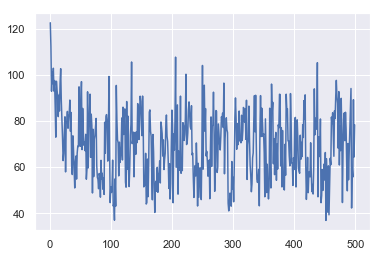

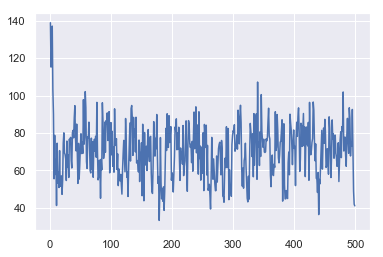

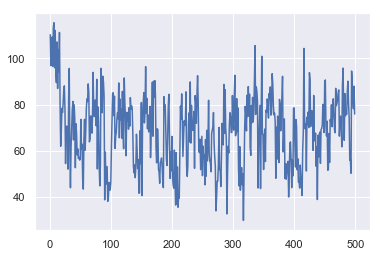

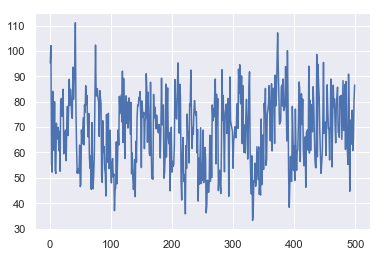

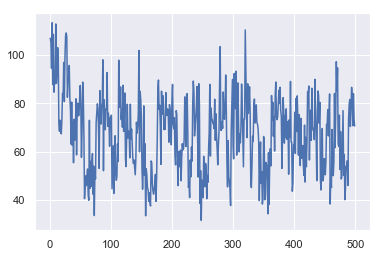

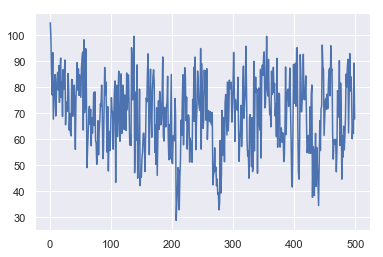

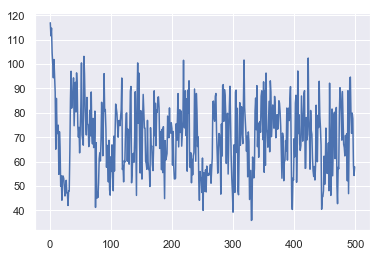

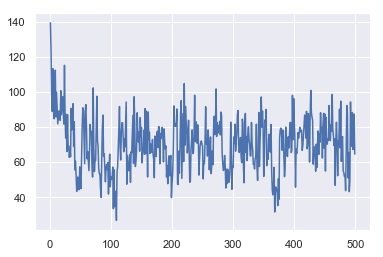

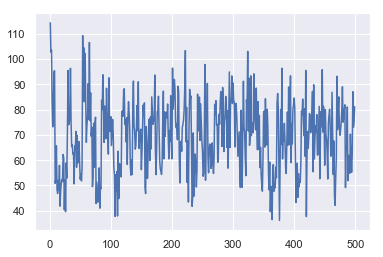

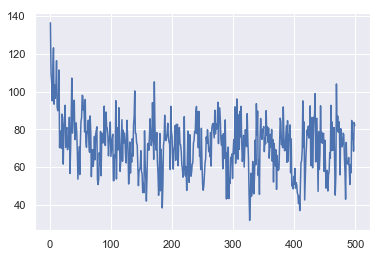

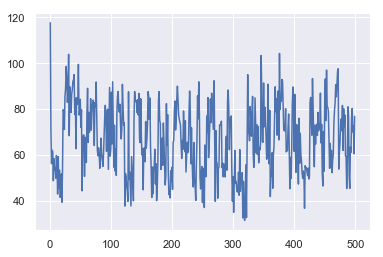

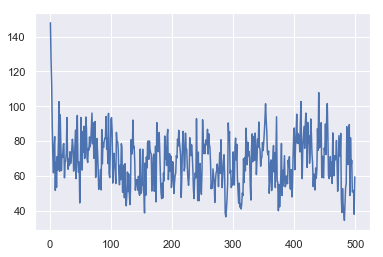

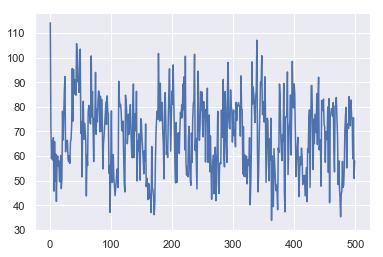

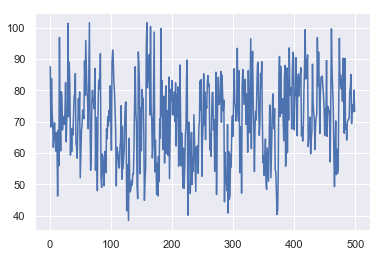

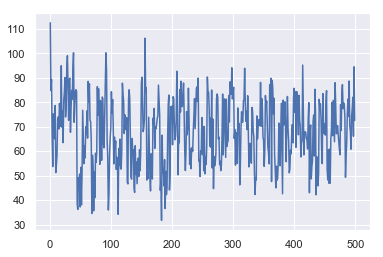

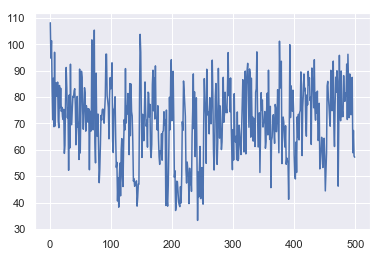

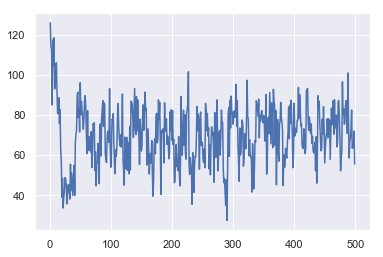

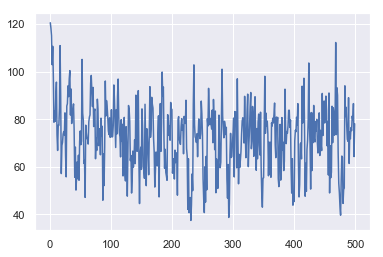

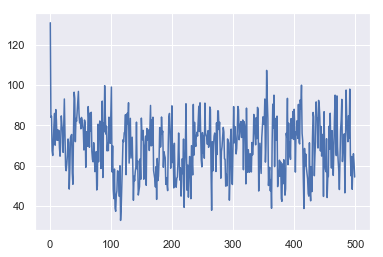

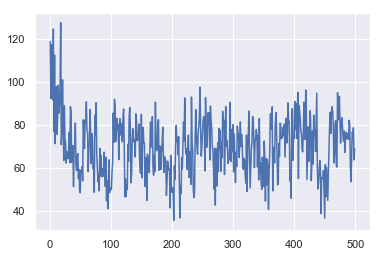

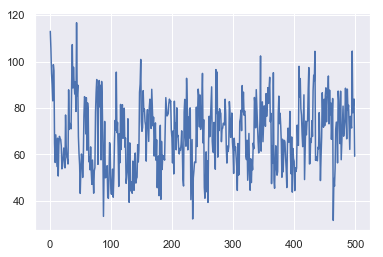

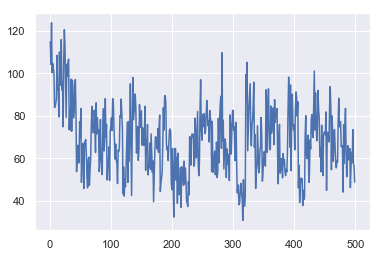

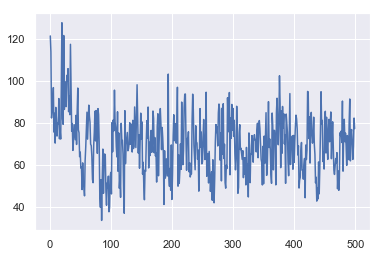

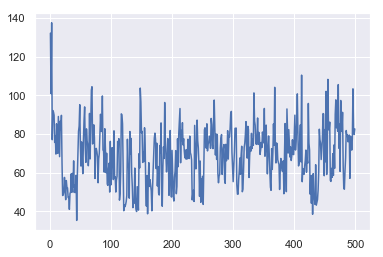

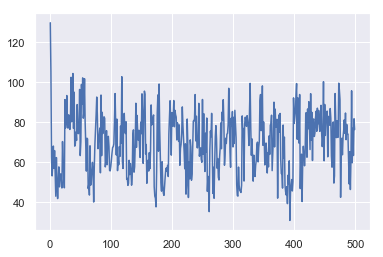

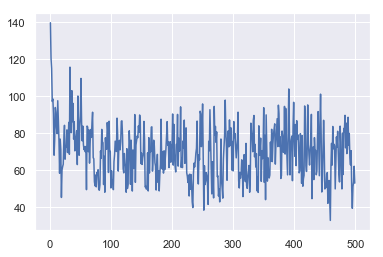

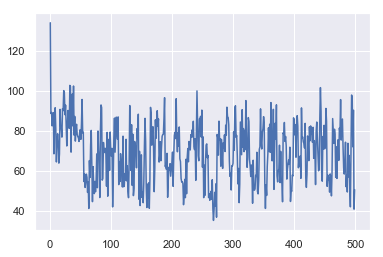

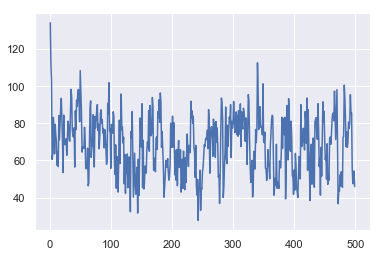

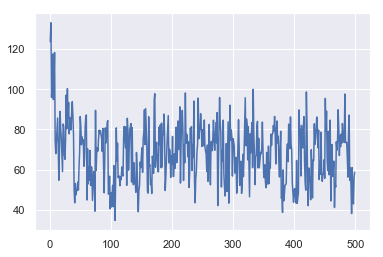

In [5]:
#This is step 2b - lets plot the individual curve for sir4
training_curve_indv("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/")

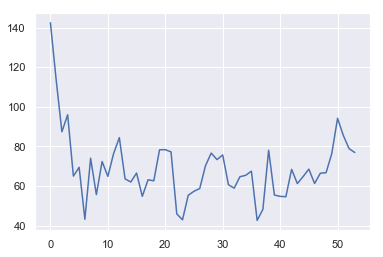

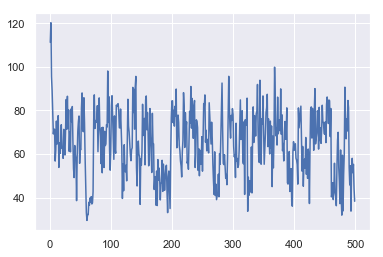

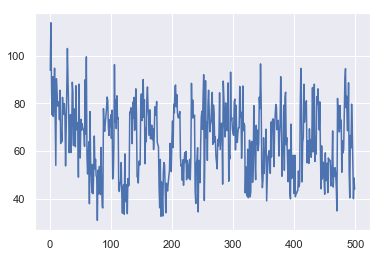

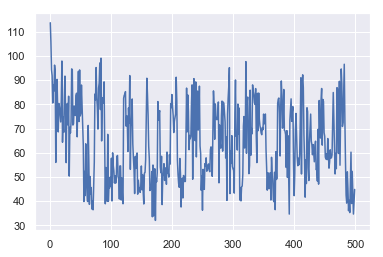

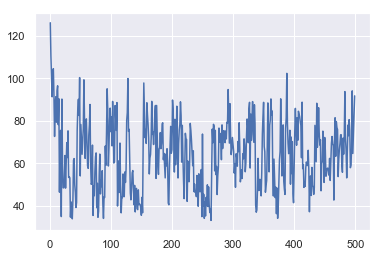

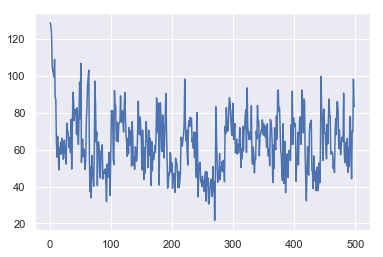

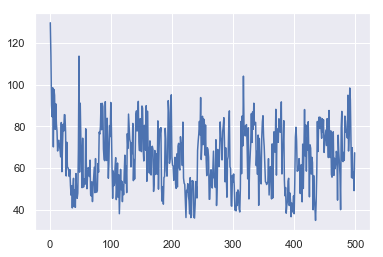

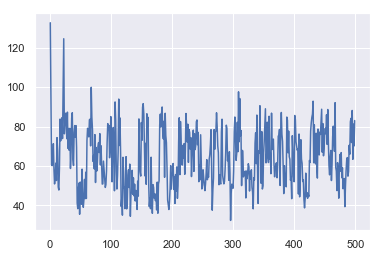

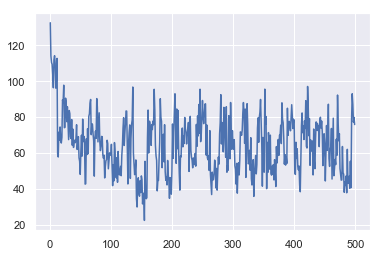

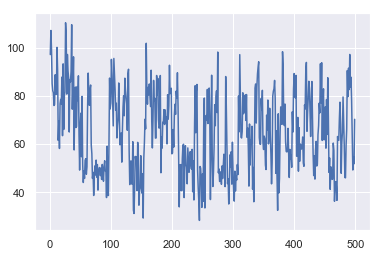

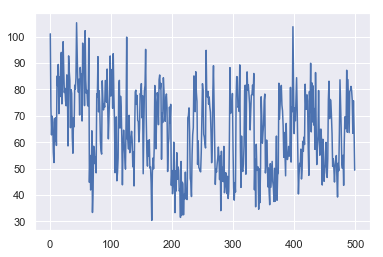

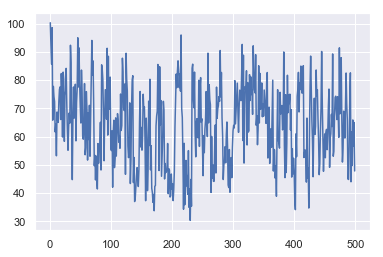

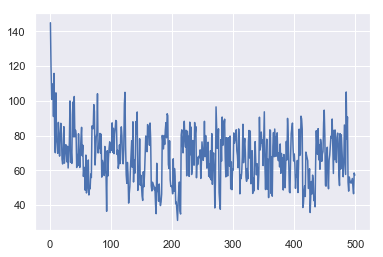

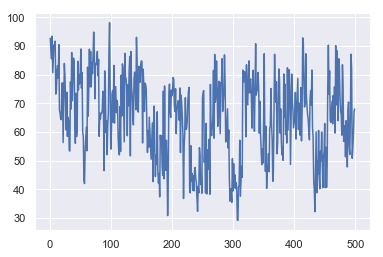

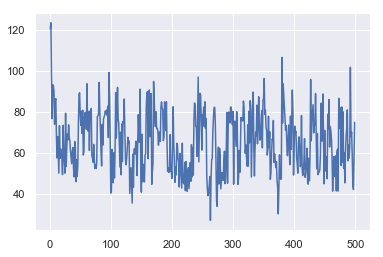

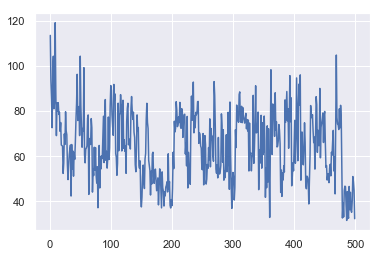

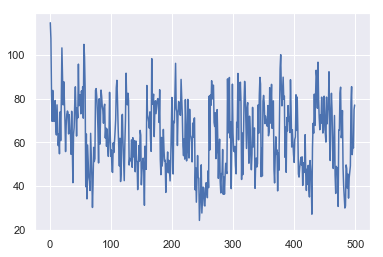

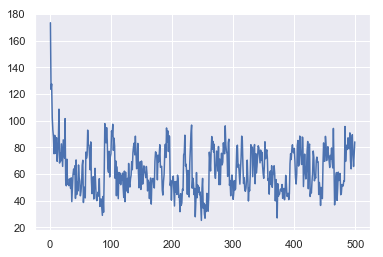

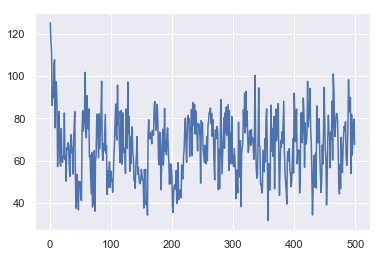

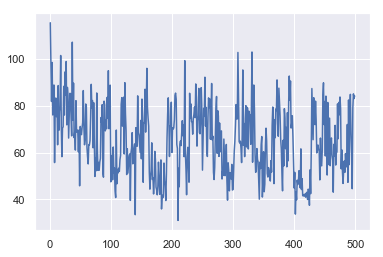

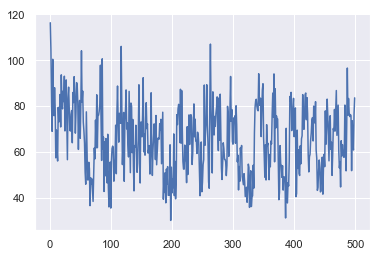

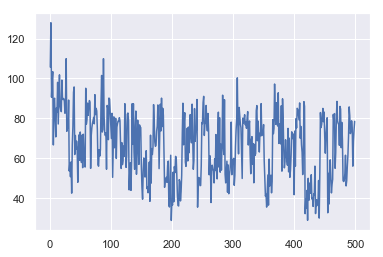

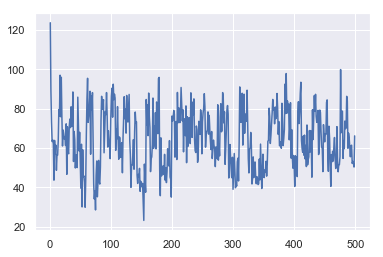

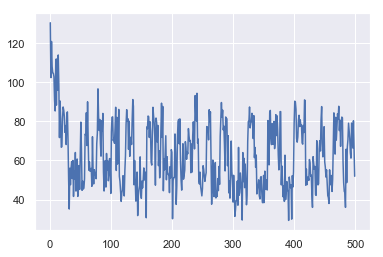

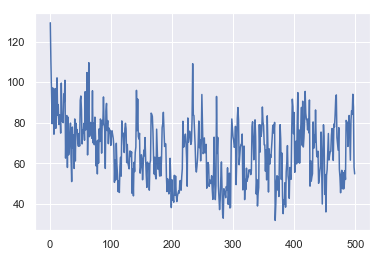

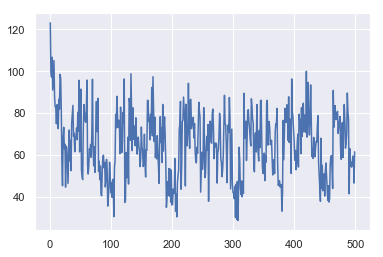

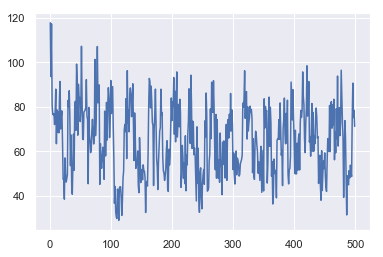

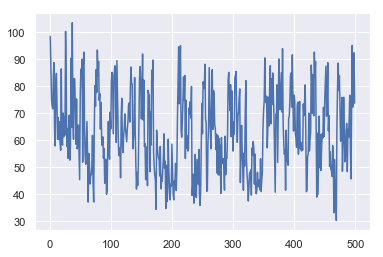

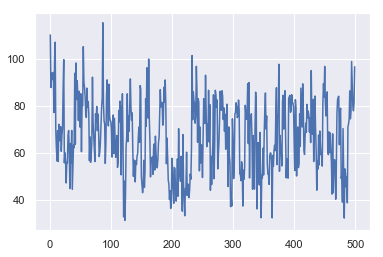

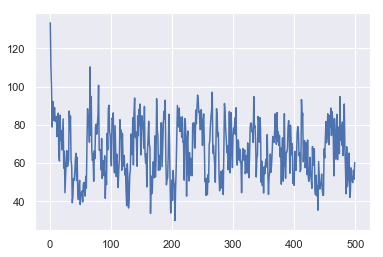

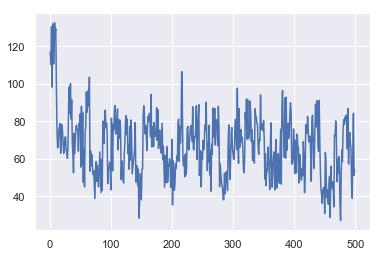

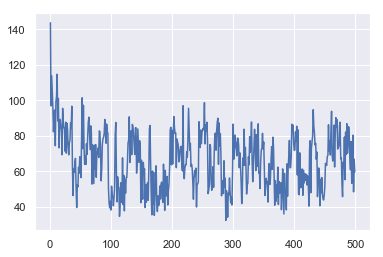

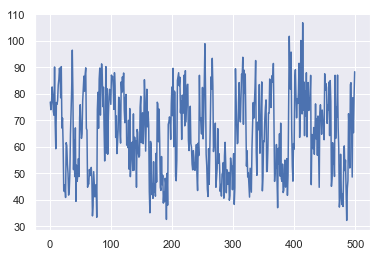

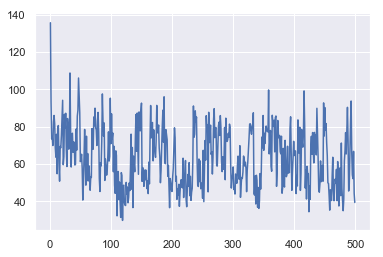

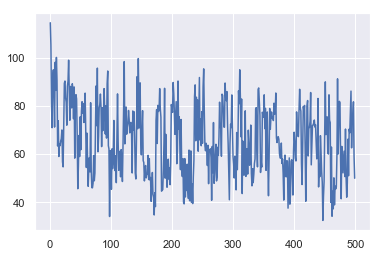

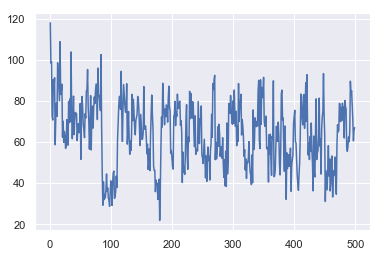

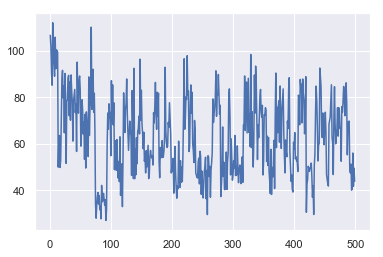

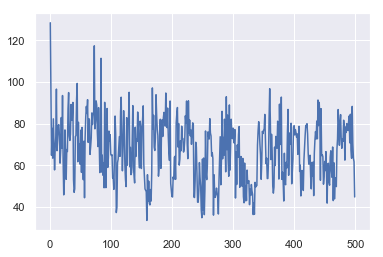

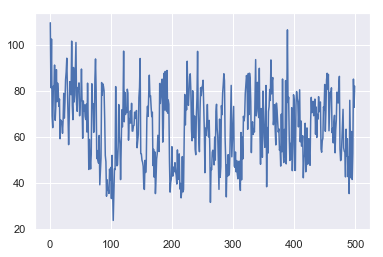

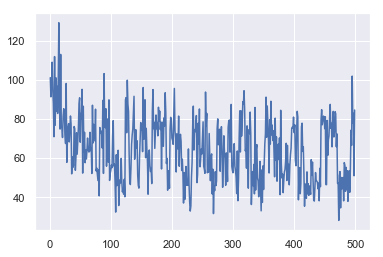

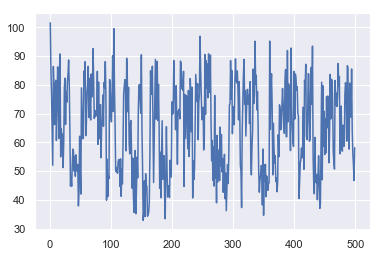

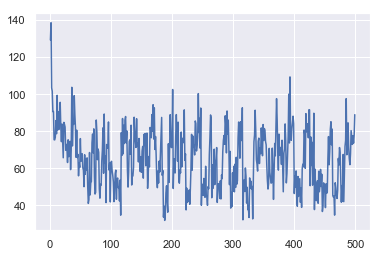

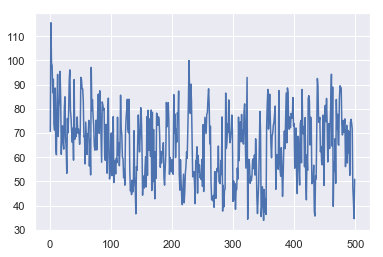

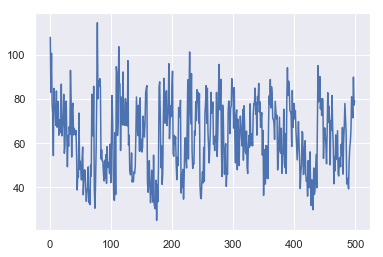

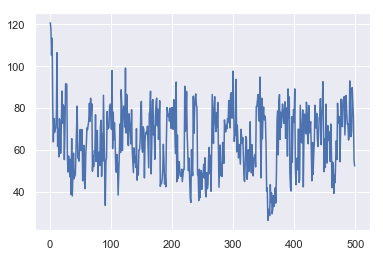

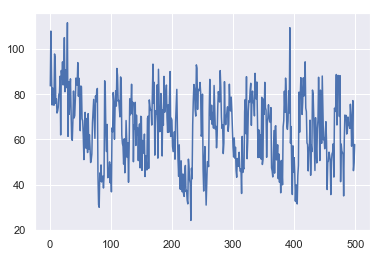

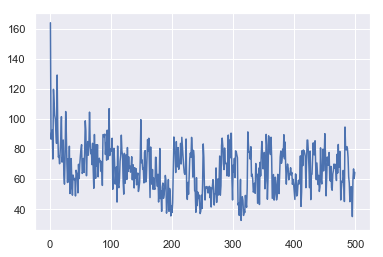

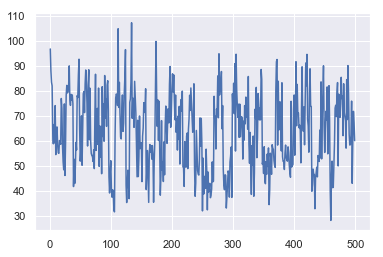

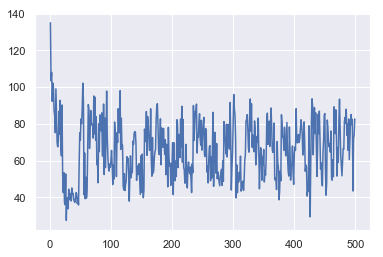

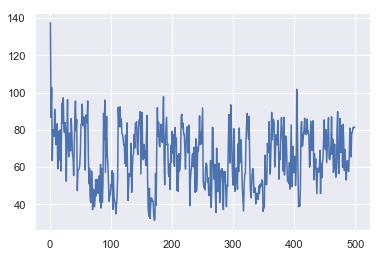

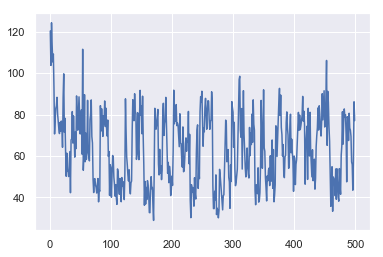

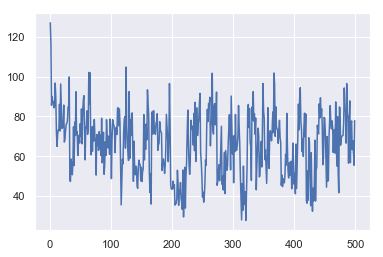

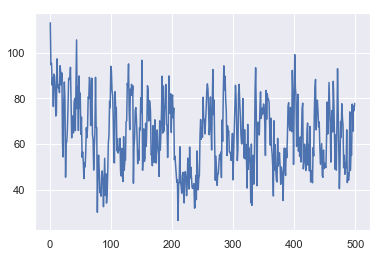

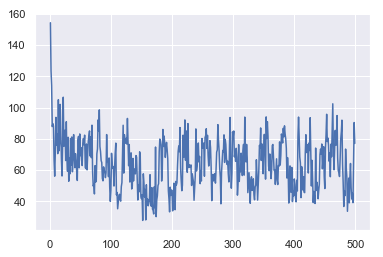

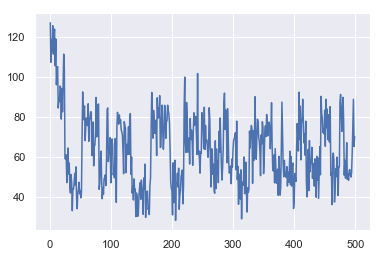

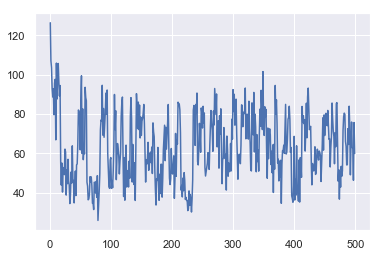

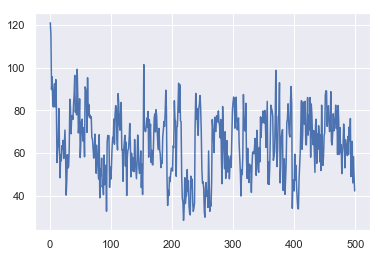

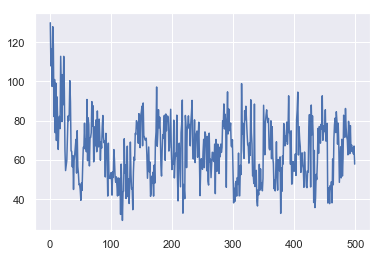

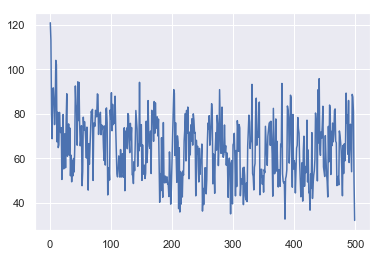

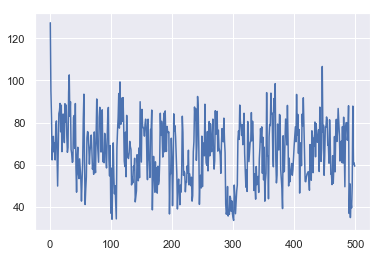

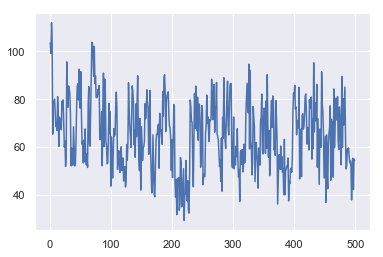

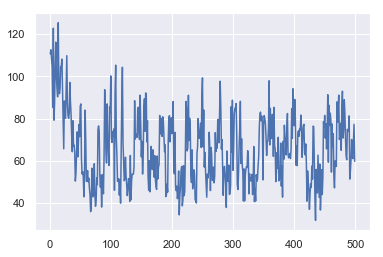

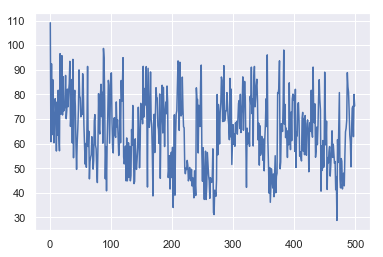

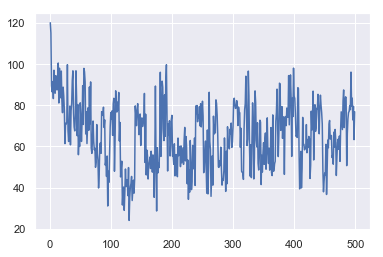

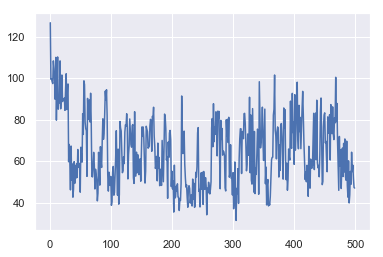

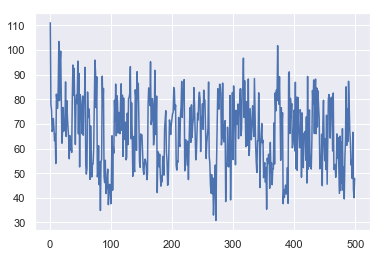

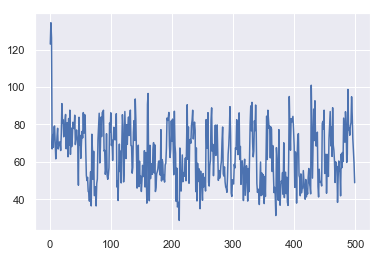

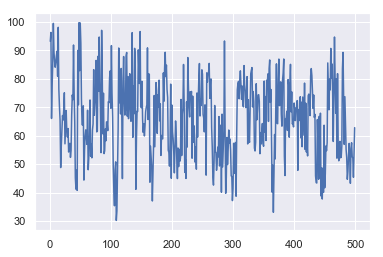

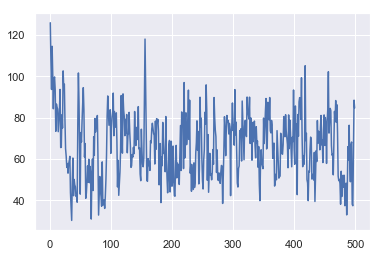

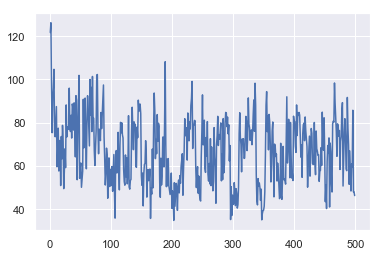

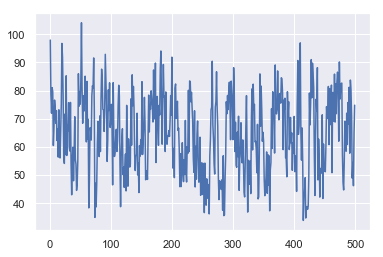

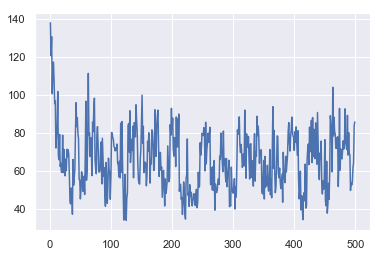

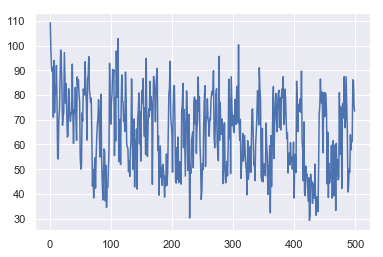

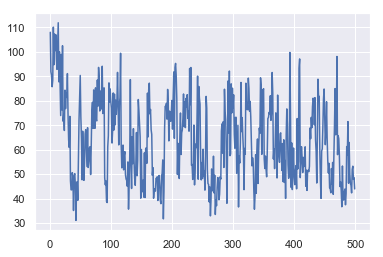

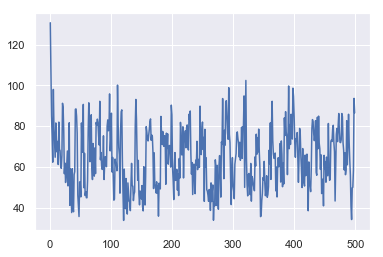

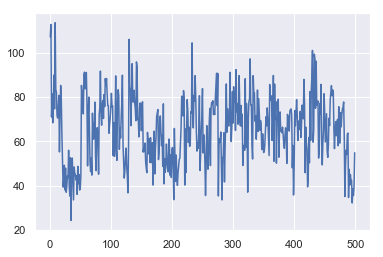

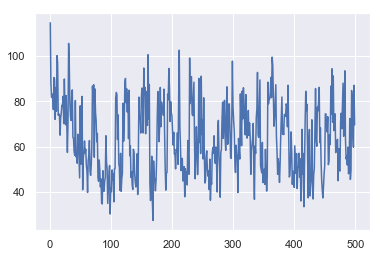

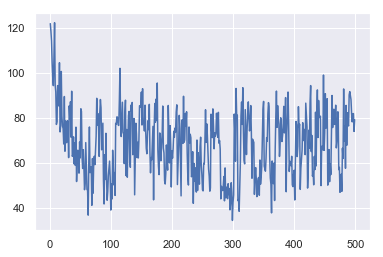

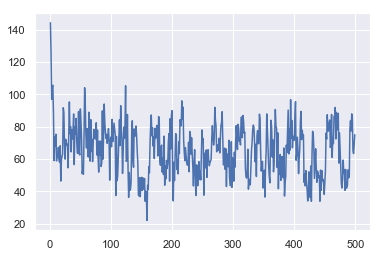

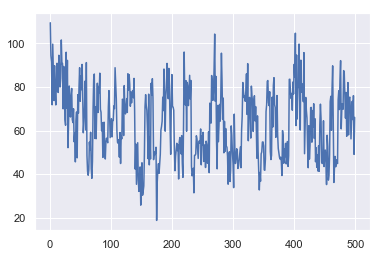

In [3]:
#This is step 2b - lets plot the individual curve for sir4
training_curve_indv("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/")

We want to try a different selection - this will have to be done manually, but can be aided with code;
Want to plot recall1 and recall2 histograms for each model and then decide based on if model learned well enough for both recall that it is fine. 

step 1) print out recall1/2 for each model 
step 2) enter good model numbers, and get bad model numbers
step 3) use the function above (plotbadmodels) plot all models that are good/bad 

In [31]:
model = []
len(model)

0

In [50]:
def plot_all_recall12(base, models = []):
    files = os.listdir(base)
    full_files = [base+f for f in files if 'EpcLog' not in f]
    full_files = [f for f in full_files if '.csv' in f]
    if len(models) != 0:
        full_files = [full_files[m] for m in models]
        
    for f in full_files:
        err = Precision()
        recall1,recall2,recall3=err.err_recall_type_sir3(f)
        plt.figure()
        model = f.split('/')[-1].split('_Stripes')[0]
        plt.hist(recall1)
        plt.title('Recall 1 Errors ,' +model)
        plt.figure()
        plt.hist(recall2)
        plt.title('Recall 2 Errors ,'+model)
        plt.figure()
        plt.hist(recall3)
        plt.title('Recall 3 Errors ,'+model)
    return full_files

['Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/hybridmodel0_RewThreshold30_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/hybridmodel10_RewThreshold30_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/hybridmodel11_RewThreshold30_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/hybridmodel12_RewThreshold30_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/hybridmodel13_RewThreshold30_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/hybridmodel14_RewThreshold30_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig

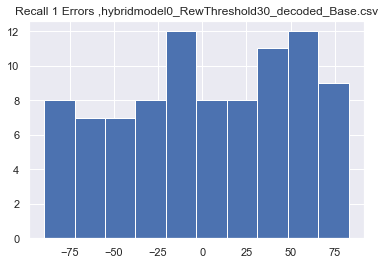

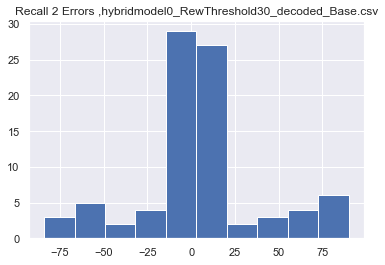

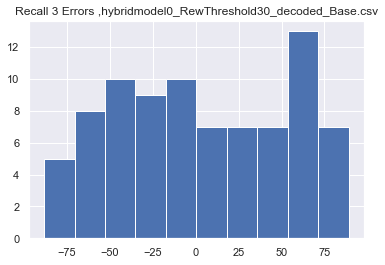

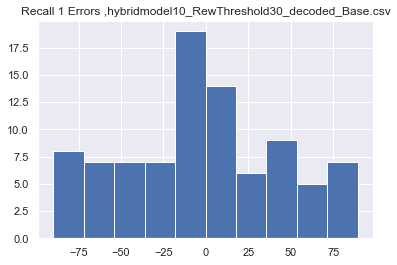

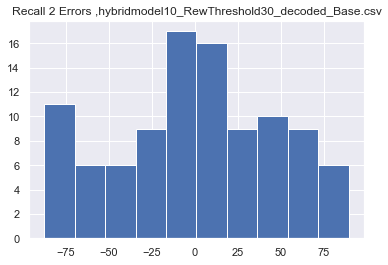

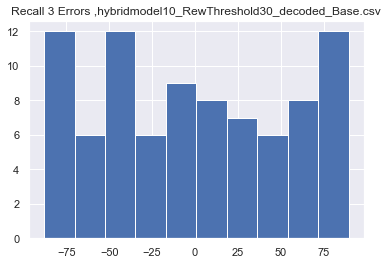

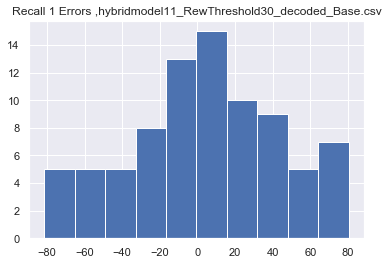

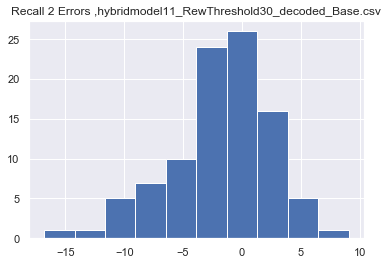

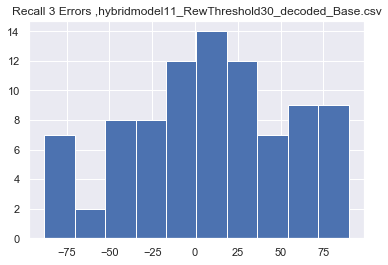

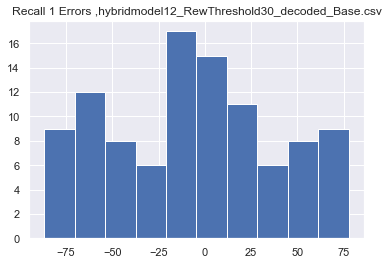

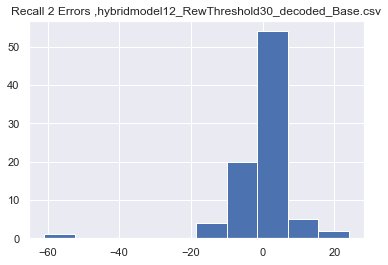

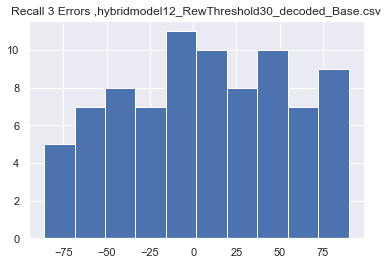

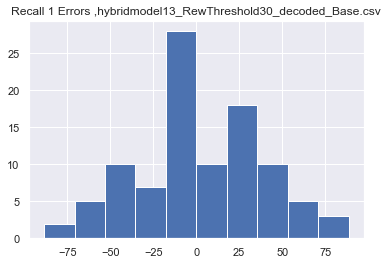

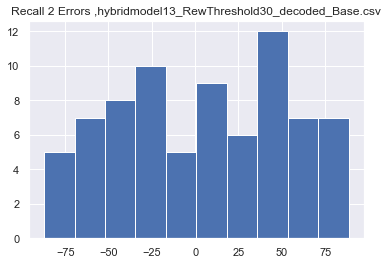

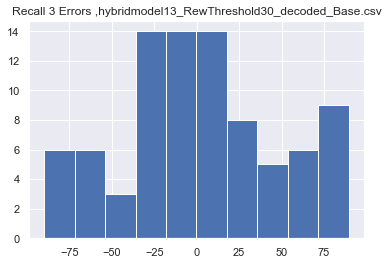

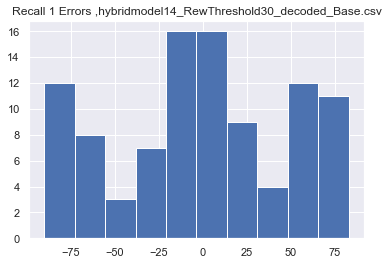

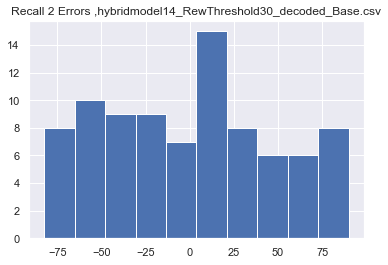

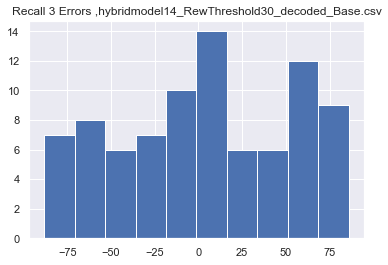

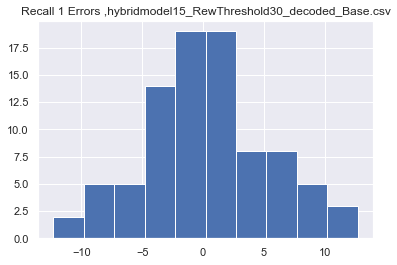

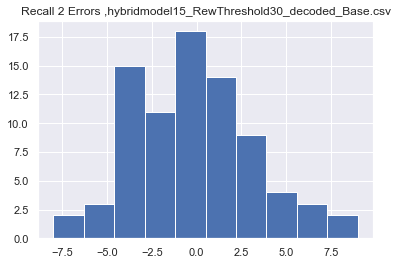

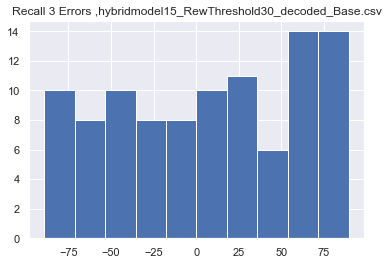

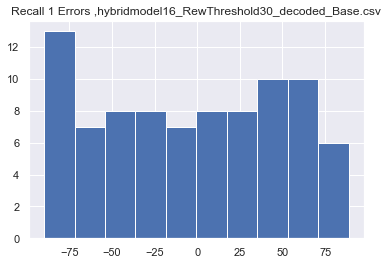

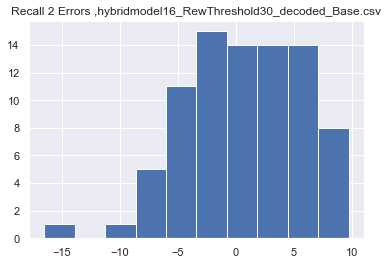

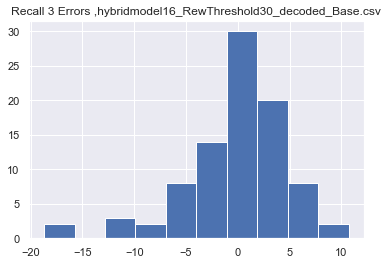

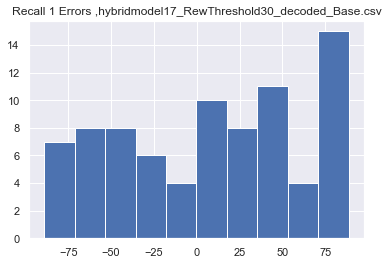

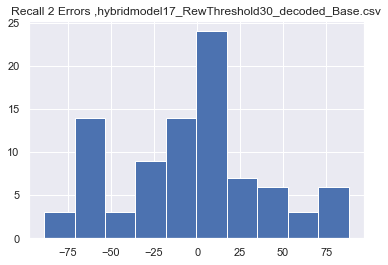

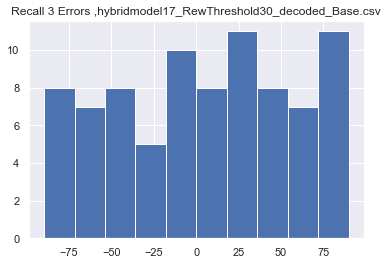

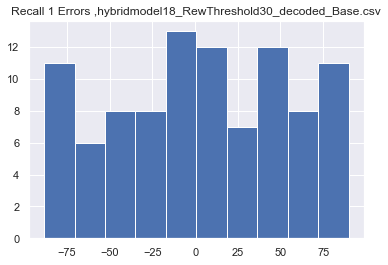

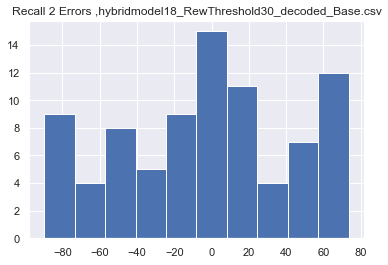

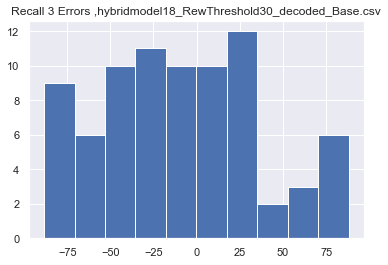

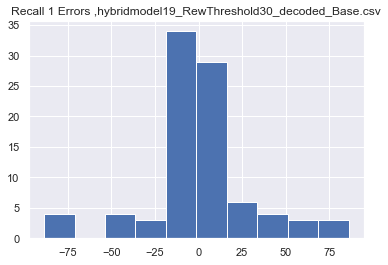

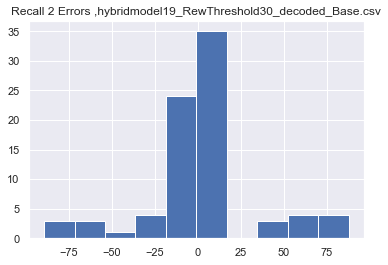

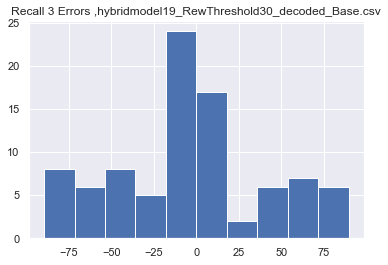

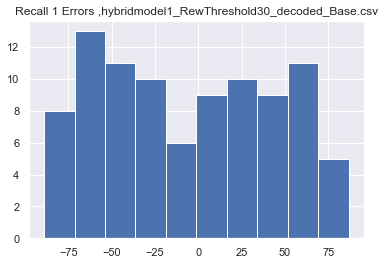

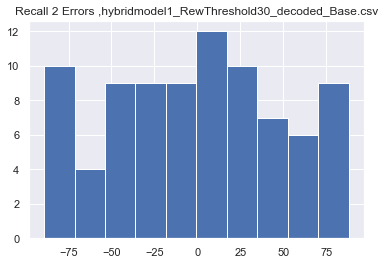

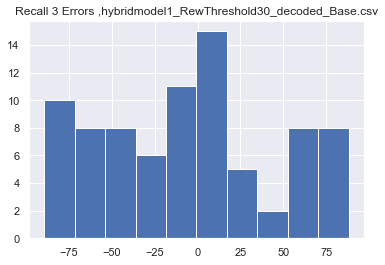

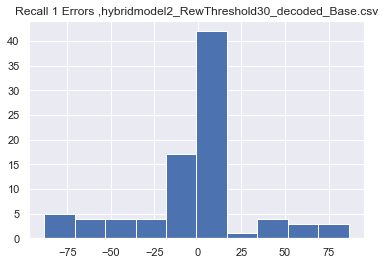

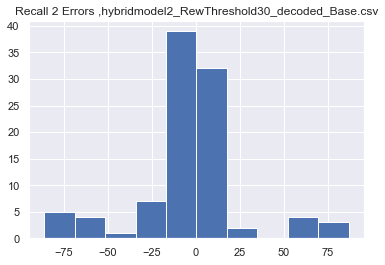

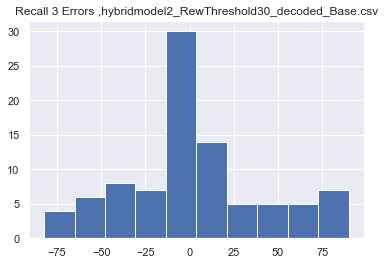

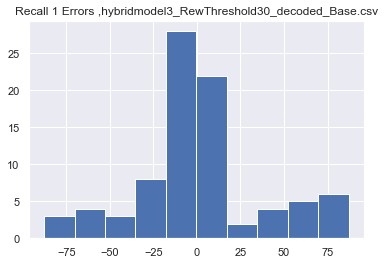

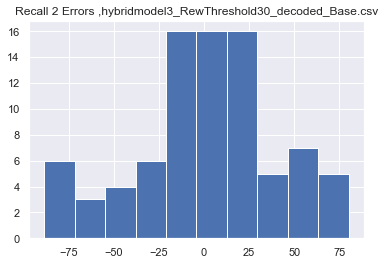

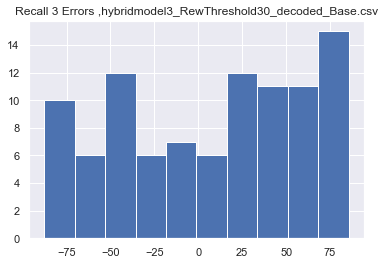

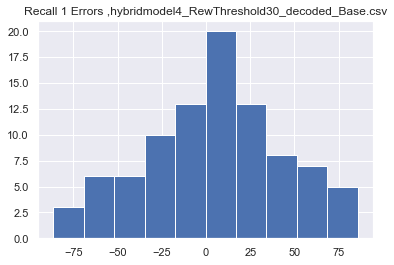

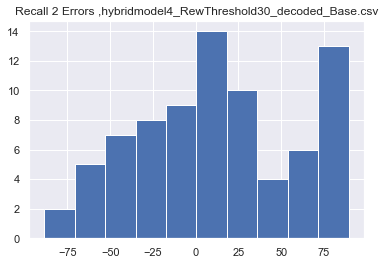

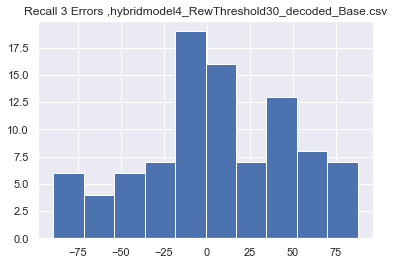

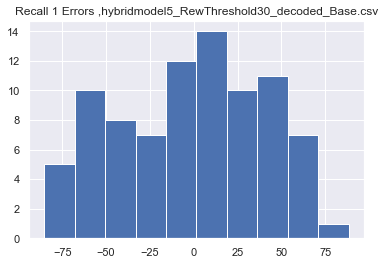

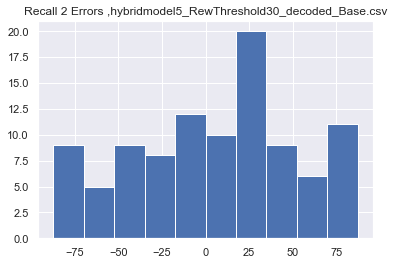

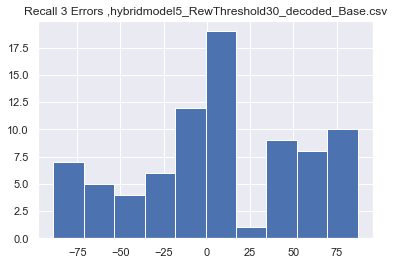

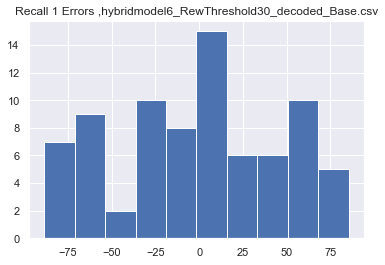

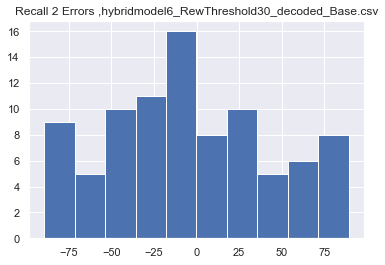

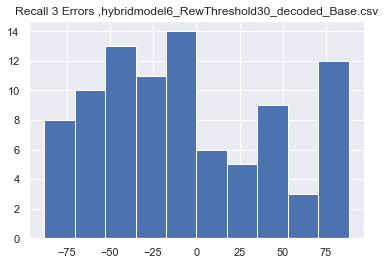

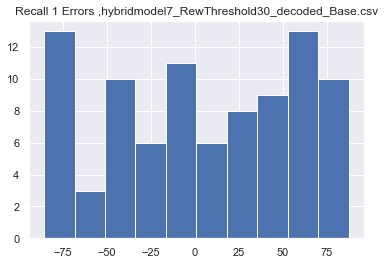

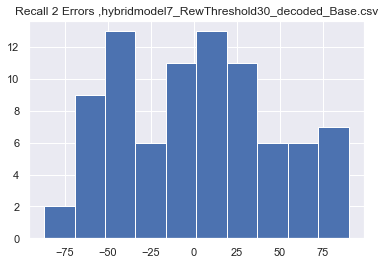

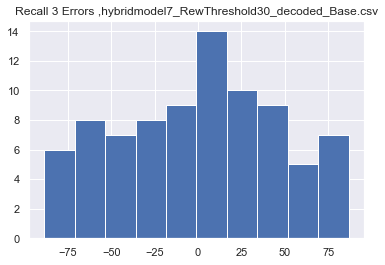

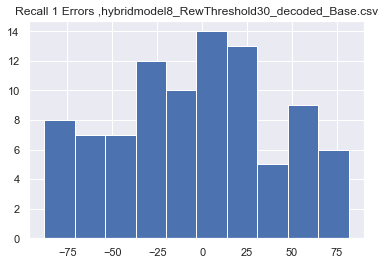

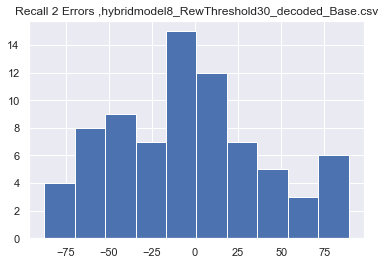

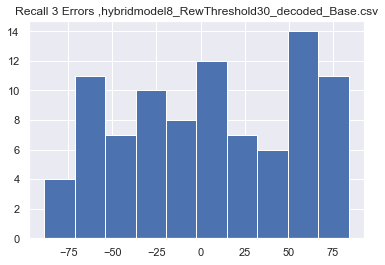

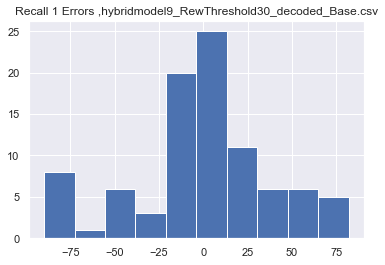

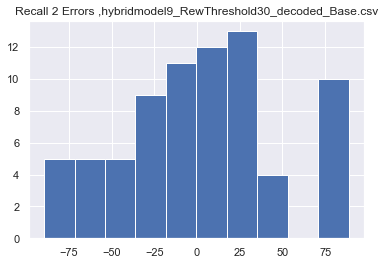

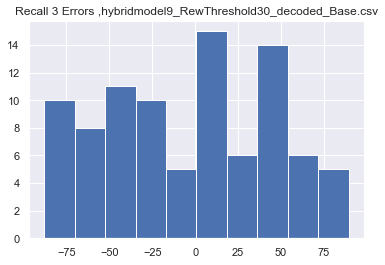

In [12]:
plot_all_recall12("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/")

In [36]:
base = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30/orig/"
files = os.listdir(base)
full_files = [base+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if '.csv' in f]
p = Precision()
err = p.mult_models(full_files)

Text(0.5, 1.0, 'One PFCmntD Stripe Projects to Chunk')

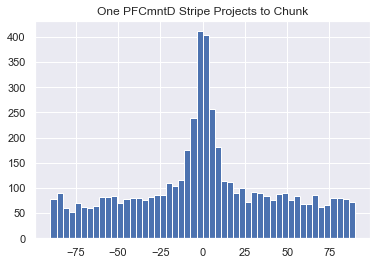

In [37]:
plt.hist(err, bins = 50)
plt.title('One PFCmntD Stripe Projects to Chunk')

In [29]:
base = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/RewThresh30/"
files = os.listdir(base)
full_files = [base+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if '.csv' in f]
p = Precision()
err =p.mult_models(full_files)


(array([ 73.,  75.,  83.,  79.,  69.,  90.,  78.,  70.,  71.,  84.,  89.,
         70.,  90.,  82.,  90.,  95.,  82.,  90., 105., 102., 114., 108.,
        127., 150., 373., 398., 188., 138., 129.,  99.,  98.,  95.,  97.,
         99.,  83., 101.,  90.,  96.,  85.,  96.,  82.,  90.,  81.,  81.,
         96.,  83.,  88.,  82.,  76.,  58.]),
 array([-9.00000e+01, -8.64026e+01, -8.28052e+01, -7.92078e+01,
        -7.56104e+01, -7.20130e+01, -6.84156e+01, -6.48182e+01,
        -6.12208e+01, -5.76234e+01, -5.40260e+01, -5.04286e+01,
        -4.68312e+01, -4.32338e+01, -3.96364e+01, -3.60390e+01,
        -3.24416e+01, -2.88442e+01, -2.52468e+01, -2.16494e+01,
        -1.80520e+01, -1.44546e+01, -1.08572e+01, -7.25980e+00,
        -3.66240e+00, -6.50000e-02,  3.53240e+00,  7.12980e+00,
         1.07272e+01,  1.43246e+01,  1.79220e+01,  2.15194e+01,
         2.51168e+01,  2.87142e+01,  3.23116e+01,  3.59090e+01,
         3.95064e+01,  4.31038e+01,  4.67012e+01,  5.02986e+01,
         5.38960e+

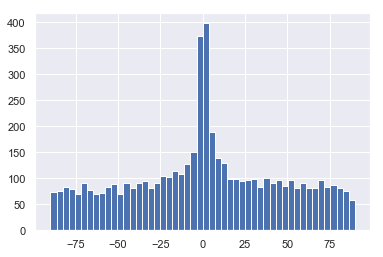

In [30]:
plt.hist(err,bins= 50)

Text(0, 0.5, 'Frequency')

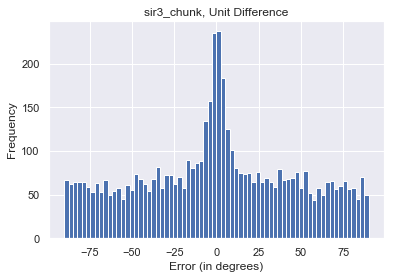

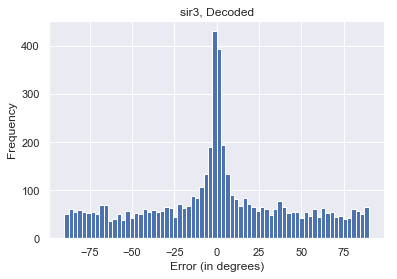

In [8]:
#This is step 1: visualize histograms for all models for sir3 and sir3 chunk (remember this is for rewthresh30) and for full range 
base_file = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh30new/"
if "StimRange0to45" in base_file:
    model_name = base_file.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base_file.split('workingmemory')[1].split('/')[1] 
if base_file.split('/')[-2] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", "+rewardfun)
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

base_file = "Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/RewThresh30new/"
if "StimRange0to45" in base_file:
    model_name = base_file.split('workingmemory')[1].split('/')[1]+' StimDist Max 45'
else:
    model_name = base_file.split('workingmemory')[1].split('/')[1] 
if base_file.split('/')[-3] == 'decodedrew':
    rewardfun = 'Decoded'
else:
    rewardfun = 'Unit Difference'
files = os.listdir(base_file)
full_files = [base_file+f for f in files if 'EpcLog' not in f]
p = Precision()
err = p.mult_models(full_files)
plt.figure()

plt.hist(err, bins = 70)
plt.title(model_name+", "+rewardfun)
plt.xlabel('Error (in degrees)')
plt.ylabel('Frequency')

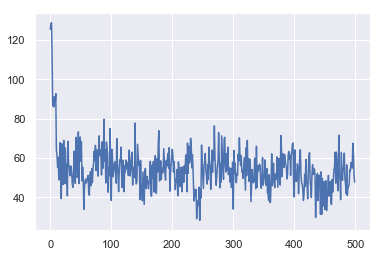

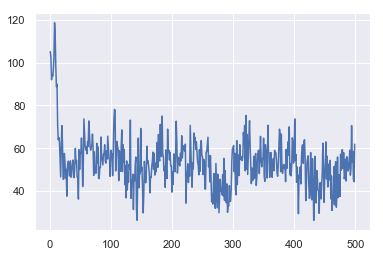

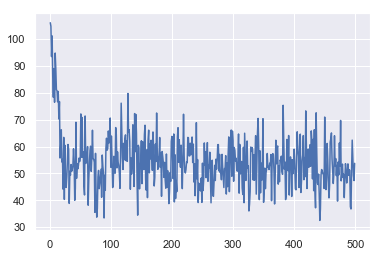

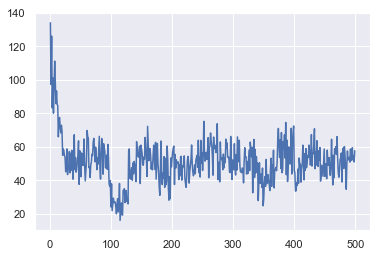

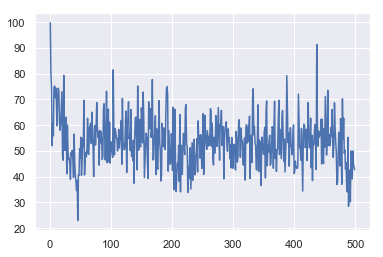

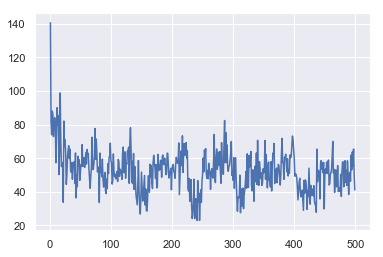

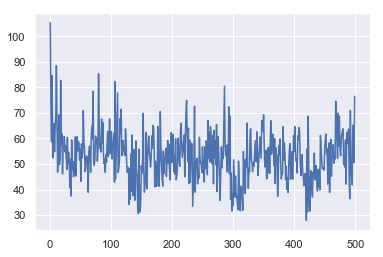

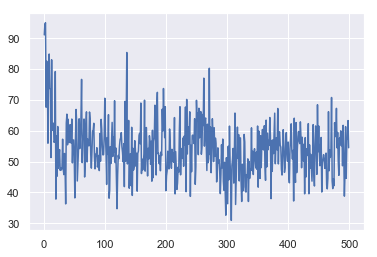

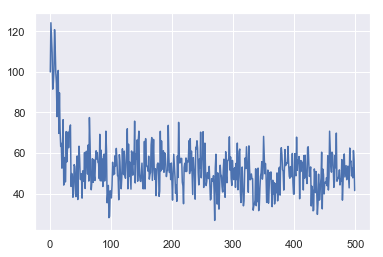

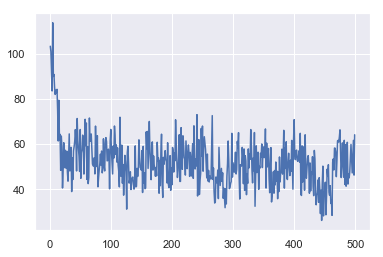

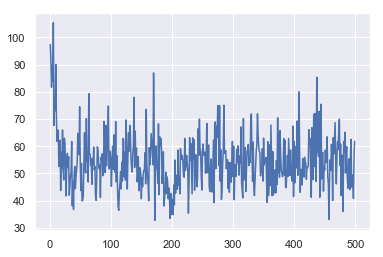

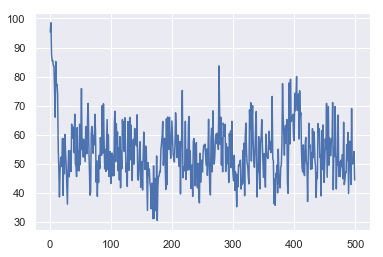

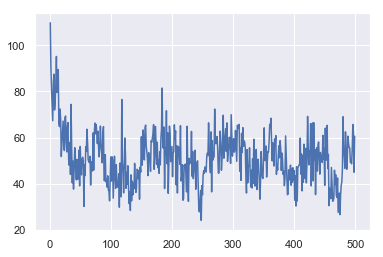

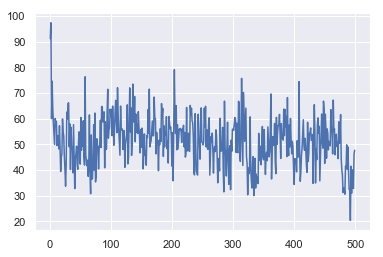

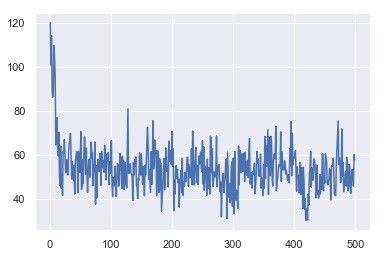

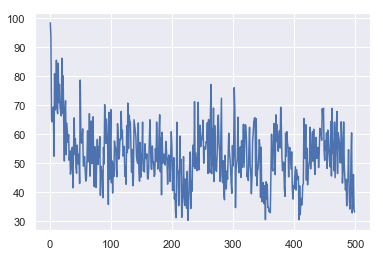

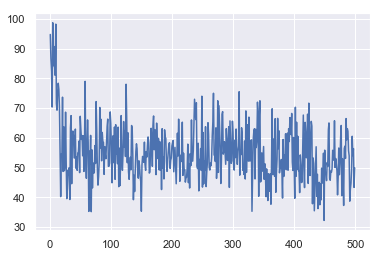

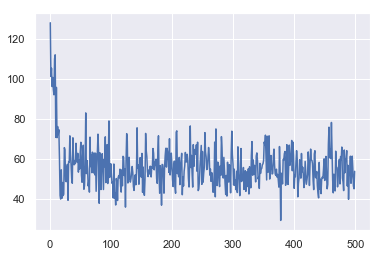

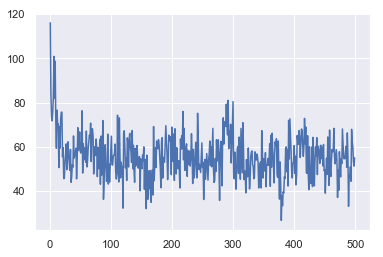

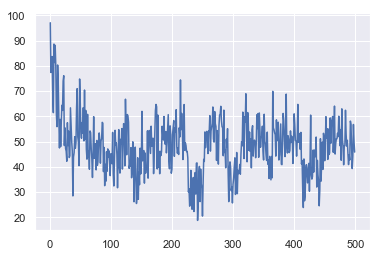

In [2]:
#This is step 2 - lets plot the inidivual curves for sir3_chunk
training_curve_indv("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/RewThresh5new/")

In [25]:
base = "Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contexp/"
files = os.listdir(base)
files = [f for f in files if '.csv' in f]
full_files = [base+f for f in files if 'EpcLog' not in f]


In [49]:
models = [1,2,3]
full_files = [full_files[m] for m in models]
full_files

['Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contexp/sir3chunkhybridmodel10_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contexp/sir3chunkhybridmodel11_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contexp/sir3chunkhybridmodel12_RewThreshold5.5_decoded_Base.csv']

(array([20., 16., 13., 27., 81., 47., 17., 21., 13.,  9.]),
 array([-87.5 , -69.85, -52.2 , -34.55, -16.9 ,   0.75,  18.4 ,  36.05,
         53.7 ,  71.35,  89.  ]),
 <a list of 10 Patch objects>)

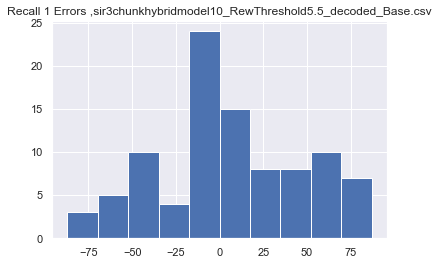

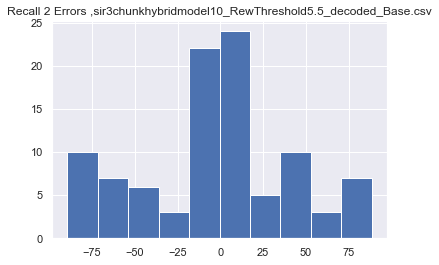

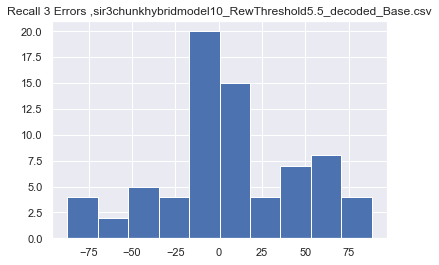

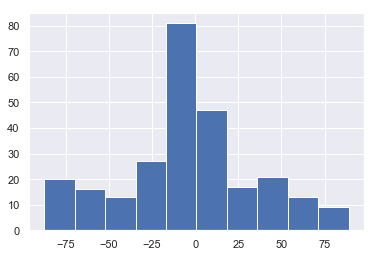

In [53]:
plot_all_recall12("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contexp/", models=[1])
plt.figure()
p = Precision()
err = p.mult_models([full_files[1]])
plt.hist(err)

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\pyplot.py:514: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


['Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model0_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model10_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model11_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model12_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model13_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model14_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model15_RewThreshold5.5_decoded_Base.csv',
 'Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/sir3model16_RewThreshold5.5_deco

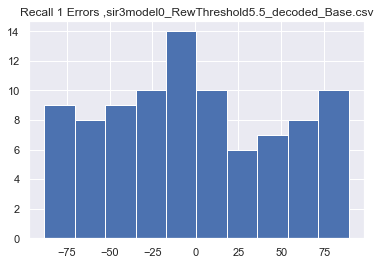

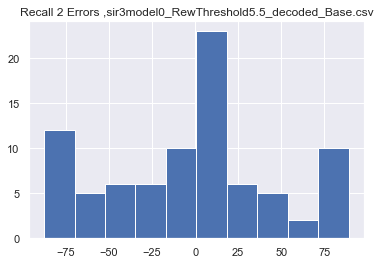

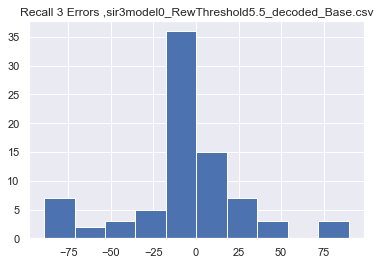

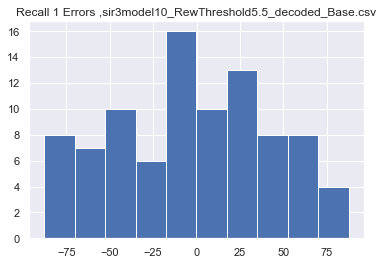

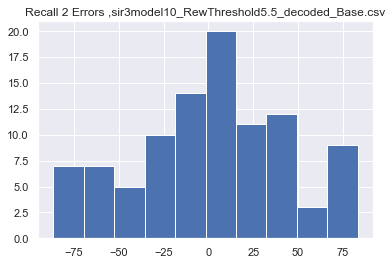

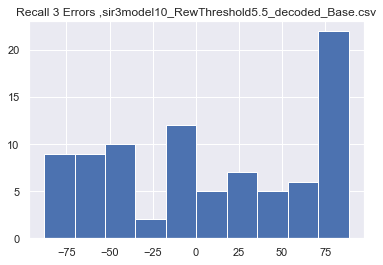

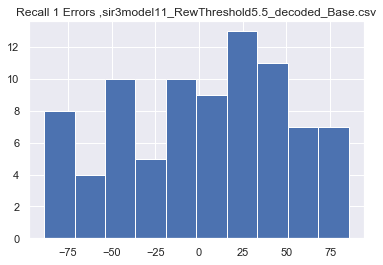

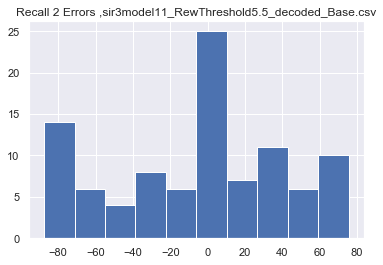

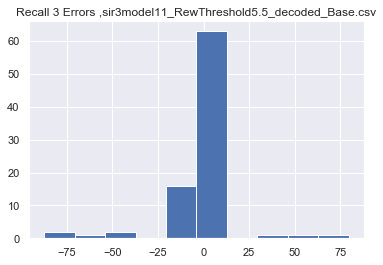

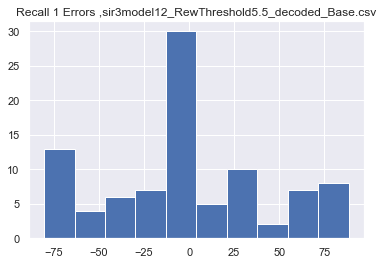

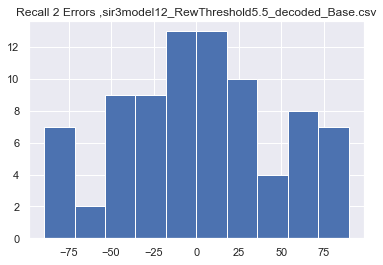

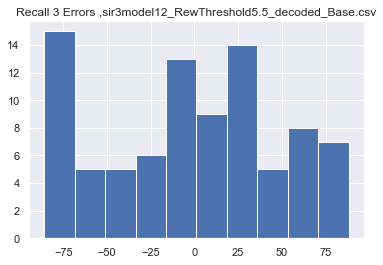

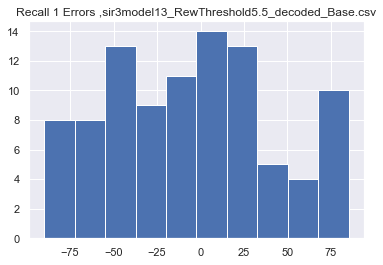

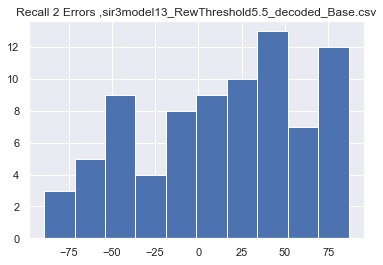

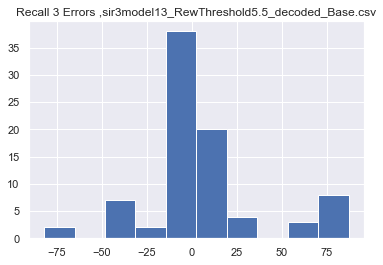

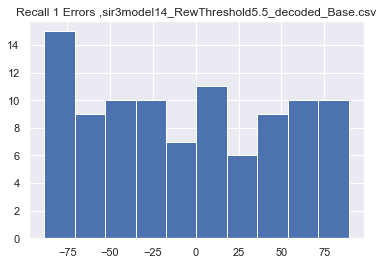

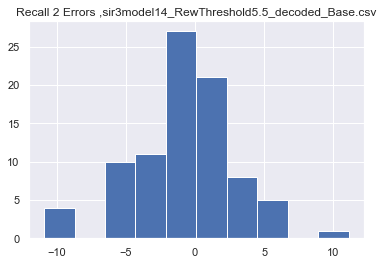

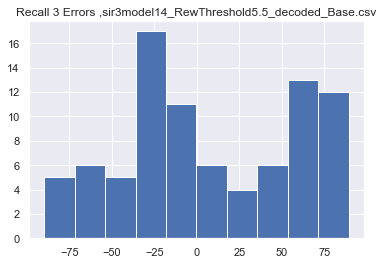

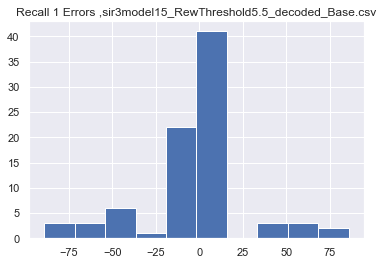

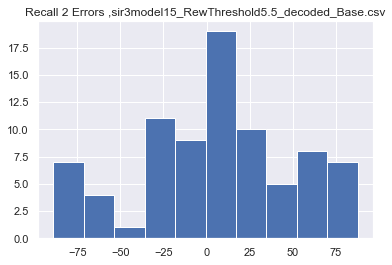

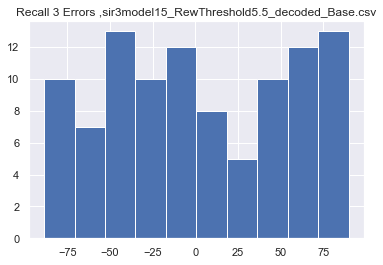

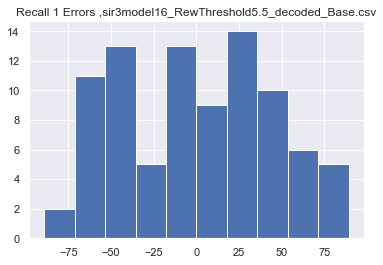

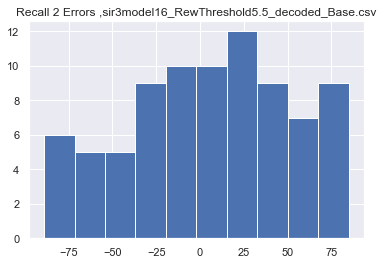

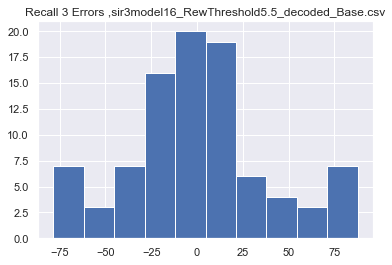

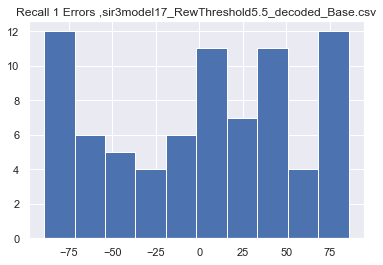

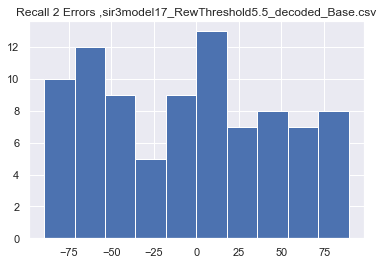

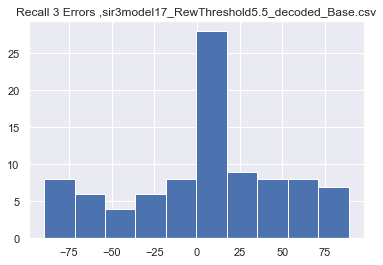

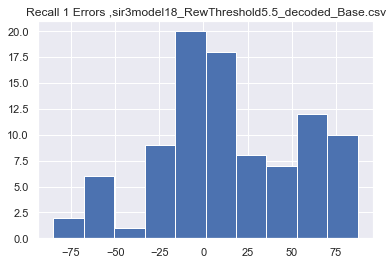

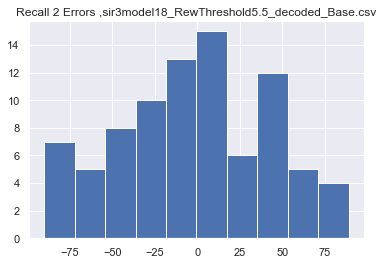

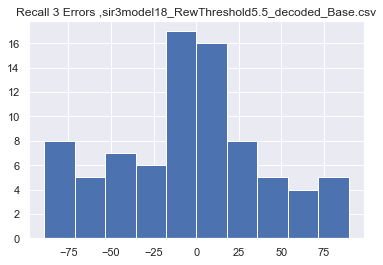

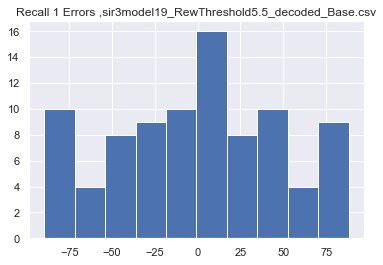

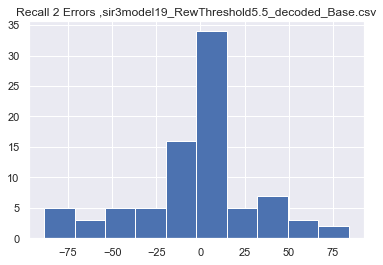

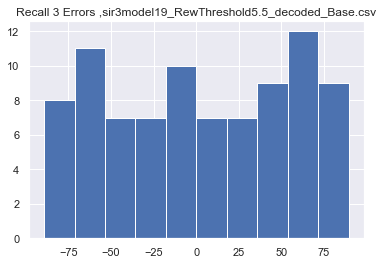

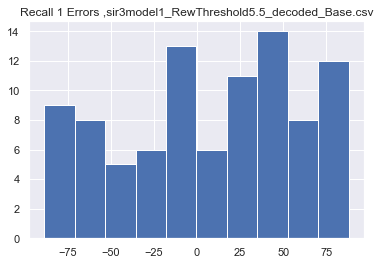

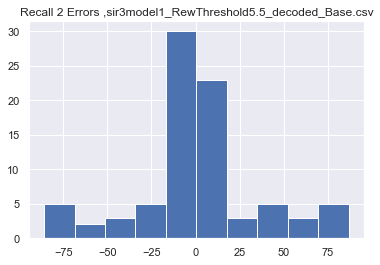

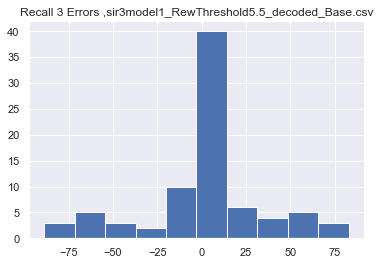

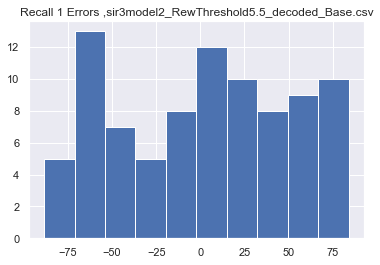

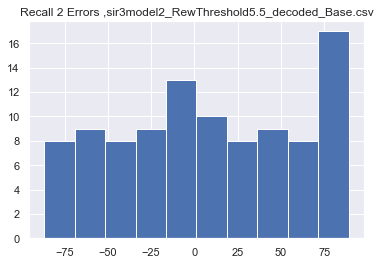

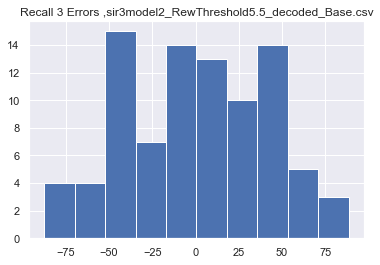

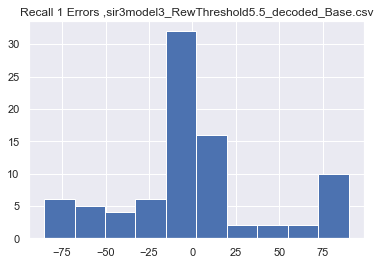

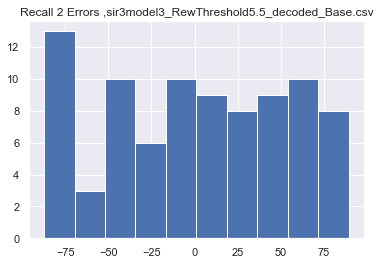

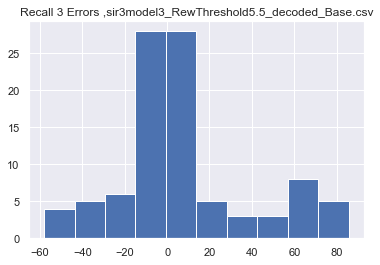

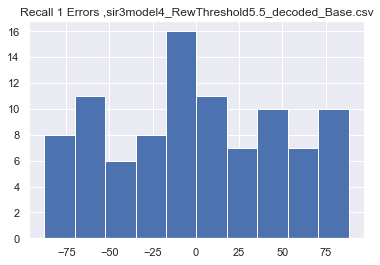

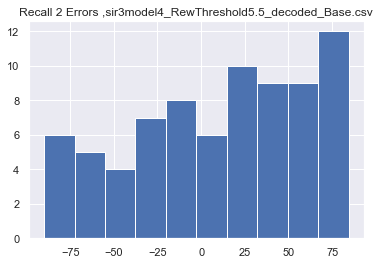

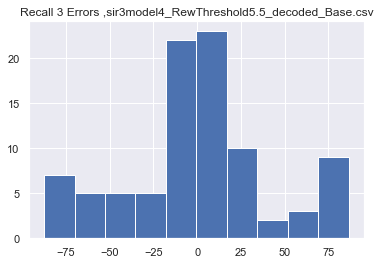

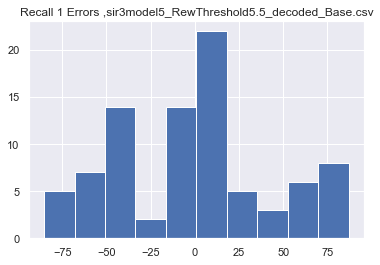

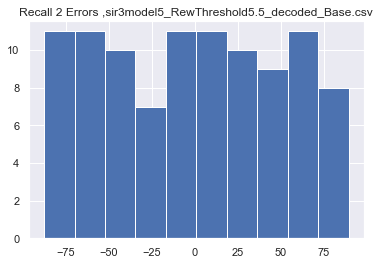

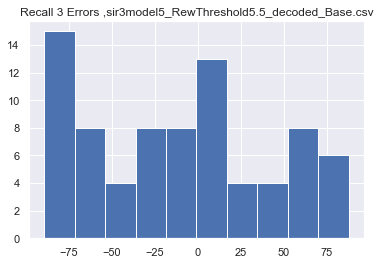

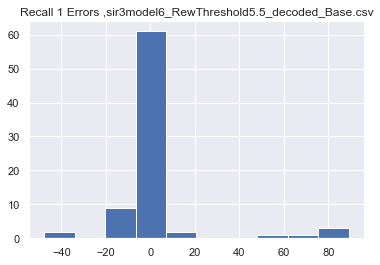

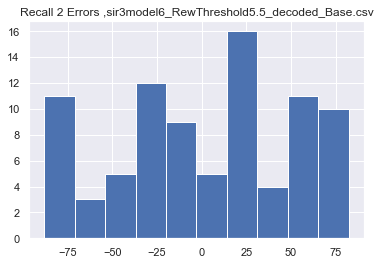

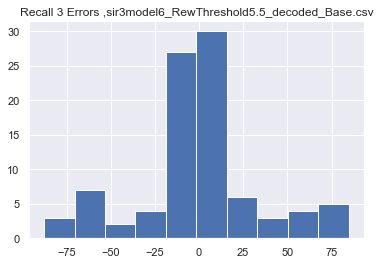

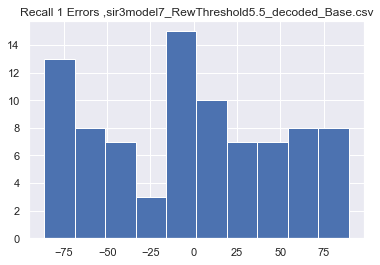

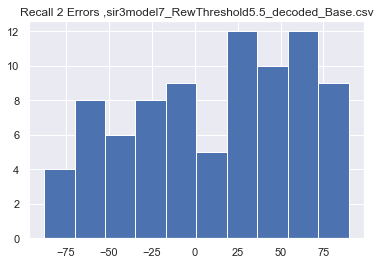

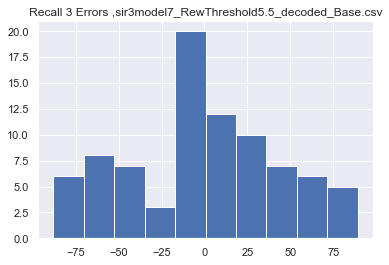

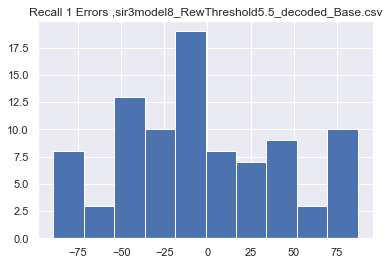

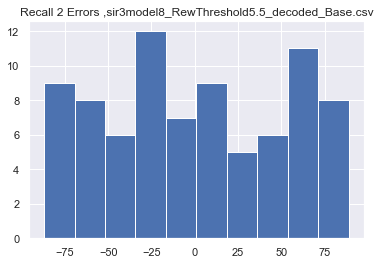

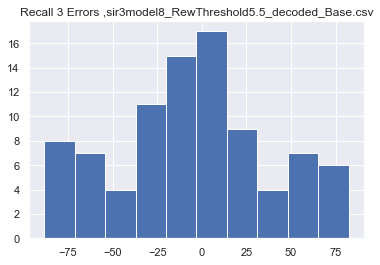

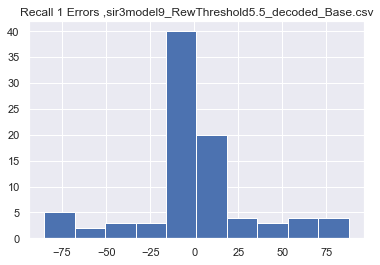

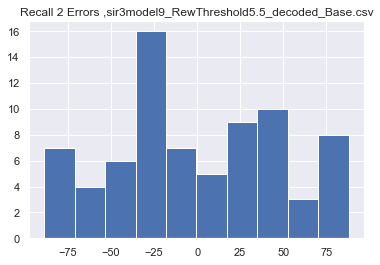

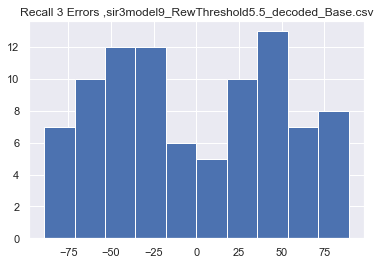

In [55]:
plot_all_recall12("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contexp/")
# plt.figure()
# p = Precision()
# err = p.mult_models([full_files[1]])
# plt.hist(err)